# Paper 1 — Final Analysis

Consolidated daily-resolution analysis of UAE respiratory consultation claims (2019–2023).

**Final data structure (one row per Date × AGEBAND × Gender × Nationality × Dependency):**

| Column | Source | Meaning |
|--------|--------|---------|
| `Date` | `treat_date` | Treatment date (daily) |
| `Exposure` | sum of `Earned_Days` | Policy-years at risk in the cell |
| `AgeBand` | `AGEBAND` | 5-year age band (e.g. 030-034) |
| `Gender` | `gender` | F / M |
| `Nationality` | grouped from `nationality` | Top 5 + Other |
| `Dependency` | grouped from `dependency` | Member / Spouse / Child / Other |
| `Consultations` | sum of `treat_consluation` | **Target variable** — claim count |

## 1. Structure the Data — Mapping & Aggregation

### 1.1 Setup

In [207]:
import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

BASE  = os.path.abspath(os.path.join('..', 'Data'))
YEARS = [2019, 2020, 2021, 2022, 2023]
FILES = {yr: os.path.join(BASE, f'Respiratory_Disease_Medical_Claims_Analysis_Daily_{yr}.csv')
         for yr in YEARS}

# Reference totals from prior Paper1 work -- used in section 1.4 for reconciliation
REF_EXPOSURE      = 1_518_634   # policy-years (sum of Earned_Days, all years)
REF_CONSULTATIONS =   486_577   # total claim count, all years
REF_UNIQUE_DAYS   =     1_826   # 2019-01-01 -> 2023-12-31 inclusive

# Minimum cell exposure -- cells below this contribute extreme rates with no
# real information. 0.001 policy-years ~= 9 hours of one member's exposure.
MIN_EXPOSURE      = 0.001

print(f'Data folder: {BASE}')
for yr, fp in FILES.items():
    status = 'OK' if os.path.exists(fp) else 'MISSING'
    size   = os.path.getsize(fp) / 1e6 if os.path.exists(fp) else 0
    print(f'  {yr}: {status:7s}  ({size:5.0f} MB)')


Data folder: c:\Users\mzafa\OneDrive\Documents\HW_PhD\ResearchWork\Data
  2019: OK       (  340 MB)
  2020: OK       (  317 MB)
  2021: OK       (  363 MB)
  2022: OK       (  376 MB)
  2023: OK       (  381 MB)


### 1.2 Categorical Mapping

Raw `nationality` and `dependency` fields have long-tail categories. To keep the GLM design matrix manageable and ensure each level has enough exposure to estimate a stable coefficient, we bucket as follows:

| Field | Kept levels | Reason |
|-------|-------------|--------|
| `Nationality` | EMIRATI, INDIAN, PAKISTANI, PHILIPPINE, BANGLADESHI, **Other** | Top 5 by exposure cover ~85% of the book |
| `Dependency` | MEMBER, SPOUSE, CHILD, **Other** | Three primary relationships + sparse residual |

`AGEBAND` and `gender` are kept as-is from the source (already pre-banded).

In [208]:
NAT_TOP5 = {'EMIRATI', 'INDIAN', 'PAKISTANI', 'PHILIPPINE', 'BANGLADESHI'}
DEP_TOP3 = {'MEMBER', 'SPOUSE', 'CHILD'}


def grp_nat(n):
    s = str(n).strip().upper()
    return s if s in NAT_TOP5 else 'Other'


def grp_dep(d):
    s = str(d).strip().upper()
    return s if s in DEP_TOP3 else 'Other'


print('Mapping functions ready.')

Mapping functions ready.


### 1.3 Load & Aggregate to the Final Grain

Each yearly CSV holds ~3.6-4.3M transaction rows. We aggregate immediately to one row per (`treat_date` x `AGEBAND` x `gender` x `nationality_grp` x `dependency_grp`), reading only the columns we need.

**Aggregations**
- `Exposure` = sum of `Earned_Days` (already a daily earned factor -> summing gives policy-years directly).
- `Consultations` = sum of `treat_consluation` (the target count).

**During load we also record per-year null counts and raw totals** so section 1.4 can audit the pipeline. No row filtering happens in this cell -- filters are applied in section 1.5 after the diagnostics.


In [209]:
READ_COLS = ['treat_date', 'AGEBAND', 'gender', 'nationality',
             'dependency', 'Earned_Days', 'treat_consluation']

GROUP_KEYS = ['treat_date', 'AGEBAND', 'gender',
              'nationality_grp', 'dependency_grp']

parts      = []
null_audit = []   # null counts captured BEFORE fillna
raw_totals = []   # raw sums BEFORE aggregation -- proves nothing dropped

for yr in YEARS:
    df = pd.read_csv(FILES[yr], usecols=READ_COLS, low_memory=False)

    null_audit.append({
        'year':        yr,
        'rows':        len(df),
        'treat_date':  df['treat_date'].isna().sum(),
        'AGEBAND':     df['AGEBAND'].isna().sum(),
        'gender':      df['gender'].isna().sum(),
        'nationality': df['nationality'].isna().sum(),
        'dependency':  df['dependency'].isna().sum(),
        'Earned_Days': df['Earned_Days'].isna().sum(),
        'consult':     df['treat_consluation'].isna().sum(),
    })

    df['treat_date']        = pd.to_datetime(df['treat_date'])
    df['treat_consluation'] = pd.to_numeric(df['treat_consluation'], errors='coerce').fillna(0)
    df['Earned_Days']       = pd.to_numeric(df['Earned_Days'],       errors='coerce').fillna(0)
    df['AGEBAND']           = df['AGEBAND'].fillna('Unknown')
    df['gender']            = df['gender'].fillna('Unknown')
    df['nationality_grp']   = df['nationality'].fillna('Other').apply(grp_nat)
    df['dependency_grp']    = df['dependency'].fillna('Other').apply(grp_dep)

    raw_totals.append({
        'year':         yr,
        'raw_exposure': df['Earned_Days'].sum(),
        'raw_consult':  df['treat_consluation'].sum(),
    })

    agg = (df.groupby(GROUP_KEYS, observed=True)
             .agg(Exposure=('Earned_Days',       'sum'),
                  Consultations=('treat_consluation', 'sum'))
             .reset_index())
    parts.append(agg)
    print(f'  {yr}: {len(df):,} raw rows  ->  {len(agg):,} aggregated cells')
    del df

panel = (pd.concat(parts, ignore_index=True)
         .rename(columns={'treat_date':       'Date',
                          'AGEBAND':          'AgeBand',
                          'gender':           'Gender',
                          'nationality_grp':  'Nationality',
                          'dependency_grp':   'Dependency'})
         .sort_values(['Date', 'AgeBand', 'Gender', 'Nationality', 'Dependency'])
         .reset_index(drop=True))

null_audit_df = pd.DataFrame(null_audit)
raw_totals_df = pd.DataFrame(raw_totals)

print(f'\nPre-filter panel: {len(panel):,} rows')


  2019: 3,823,903 raw rows  ->  134,387 aggregated cells
  2020: 3,604,702 raw rows  ->  132,835 aggregated cells
  2021: 4,098,743 raw rows  ->  129,711 aggregated cells
  2022: 4,237,607 raw rows  ->  128,469 aggregated cells
  2023: 4,307,301 raw rows  ->  134,359 aggregated cells

Pre-filter panel: 659,761 rows


### 1.4 Data Quality Diagnostics

Five checks, each addressing a specific risk we've seen in prior Paper1 work:

1. **Null counts** in the raw CSVs (should be tiny -- confirms fillna doesn't mask big gaps).
2. **AgeBand level inventory** -- prior work flagged an `Out of range` band that produced an unstable IRR ~ 35 in the GLM.
3. **Date completeness** -- expect exactly 1,826 unique days (2019-01-01 -> 2023-12-31, no gaps).
4. **Exposure distribution** -- identify sparse cells that need the `MIN_EXPOSURE` filter.
5. **Totals reconciliation** -- pre-aggregation sums must match post-aggregation sums and the known reference.


In [210]:
print('Check 1 -- Null counts in raw CSVs (before fillna)')
display(null_audit_df)

total_nulls = null_audit_df.drop(columns=['year', 'rows']).sum().sum()
if total_nulls == 0:
    print('PASS: no nulls in any read column.')
else:
    print(f'INFO: {int(total_nulls):,} null cells found. They were filled to '
          "Unknown / Other / 0 in section 1.3 -- inspect the table above to confirm the affected columns are categorical.")


Check 1 -- Null counts in raw CSVs (before fillna)


,year,rows,treat_date,AGEBAND,gender,nationality,dependency,Earned_Days,consult
0,2019,3823903,0,0,0,30345,0,0,0
1,2020,3604702,0,0,0,22947,0,0,0
2,2021,4098743,0,0,0,20701,0,0,0
3,2022,4237607,0,0,0,21627,0,0,0
4,2023,4307301,0,0,0,9501,0,0,0


INFO: 105,121 null cells found. They were filled to Unknown / Other / 0 in section 1.3 -- inspect the table above to confirm the affected columns are categorical.


In [211]:
print('Check 2 -- AgeBand level inventory')
ageband_stats = (panel.groupby('AgeBand', observed=True)
                       .agg(rows=('Date', 'size'),
                            exposure=('Exposure', 'sum'),
                            consultations=('Consultations', 'sum'))
                       .reset_index()
                       .sort_values('exposure', ascending=False))
ageband_stats['exposure_pct'] = ageband_stats['exposure'] / ageband_stats['exposure'].sum() * 100
display(ageband_stats.round({'exposure': 0, 'exposure_pct': 3}))

anomalous = ageband_stats[ageband_stats['AgeBand'].isin(['Out of range', 'Unknown'])]
if anomalous.empty:
    print('PASS: no anomalous AgeBand values.')
else:
    pct = anomalous['exposure_pct'].sum()
    print(f'WARN: anomalous AgeBand values present, '
          f'covering {pct:.4f}%% of exposure. Will be filtered in section 1.5.')


Check 2 -- AgeBand level inventory


,AgeBand,rows,exposure,consultations,exposure_pct
0,000-014,23920,277165.0,181968,18.251
4,030-034,63186,257772.0,64510,16.974
5,035-039,56984,228271.0,63879,15.031
3,025-029,61259,219831.0,42909,14.476
6,040-044,55308,159647.0,45649,10.513
2,020-024,59212,115459.0,18243,7.603
7,045-049,55020,99480.0,27236,6.551
8,050-054,53883,58428.0,15367,3.847
1,015-019,49588,50767.0,12851,3.343
9,055-059,49949,31747.0,8629,2.090


WARN: anomalous AgeBand values present, covering 0.0001%% of exposure. Will be filtered in section 1.5.


In [212]:
print('Check 3 -- Date completeness')
n_days = panel['Date'].nunique()
first  = panel['Date'].min()
last   = panel['Date'].max()
expected_range = pd.date_range(first, last, freq='D')
missing = sorted(set(expected_range) - set(panel['Date'].unique()))

print(f'  Unique dates       : {n_days:,}  (reference: {REF_UNIQUE_DAYS:,})')
print(f'  Range              : {first.date()} -> {last.date()}')
print(f'  Missing days in range: {len(missing)}')
if missing:
    print('    ->', missing[:10], '...' if len(missing) > 10 else '')
if n_days == REF_UNIQUE_DAYS and not missing:
    print('PASS: every calendar day in 2019-2023 is represented.')
else:
    print('WARN: date coverage differs from reference -- investigate.')


Check 3 -- Date completeness
  Unique dates       : 1,826  (reference: 1,826)
  Range              : 2019-01-01 -> 2023-12-31
  Missing days in range: 0
PASS: every calendar day in 2019-2023 is represented.


In [213]:
print('Check 4 -- Cell exposure distribution')
exp_desc = panel['Exposure'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
display(exp_desc.round(4))

n_zero  = (panel['Exposure'] == 0).sum()
n_tiny  = ((panel['Exposure'] > 0) & (panel['Exposure'] < MIN_EXPOSURE)).sum()
print(f'  Zero-exposure cells           : {n_zero:,}')
print(f'  Tiny cells (0 < e < {MIN_EXPOSURE}) : {n_tiny:,}')
print(f'  Will be filtered in section 1.5: {n_zero + n_tiny:,}')


Check 4 -- Cell exposure distribution


count    659761.0000
mean          2.3018
std           5.8741
min           0.0025
1%            0.0027
5%            0.0027
25%           0.0137
50%           0.1680
75%           1.5174
95%          13.0157
99%          33.1379
max          55.7769
Name: Exposure, dtype: float64

  Zero-exposure cells           : 0
  Tiny cells (0 < e < 0.001) : 0
  Will be filtered in section 1.5: 0


In [214]:
print('Check 5 -- Totals reconciliation')

raw_exp_total     = raw_totals_df['raw_exposure'].sum()
raw_consult_total = raw_totals_df['raw_consult'].sum()
panel_exp_total   = panel['Exposure'].sum()
panel_consult     = panel['Consultations'].sum()

recon = pd.DataFrame({
    'Metric':       ['Exposure (policy-years)', 'Consultations'],
    'Raw_total':    [raw_exp_total,     raw_consult_total],
    'Panel_total':  [panel_exp_total,   panel_consult],
    'Reference':    [REF_EXPOSURE,      REF_CONSULTATIONS],
})
recon['agg_loss']    = recon['Raw_total']  - recon['Panel_total']
recon['ref_delta_pct'] = (recon['Panel_total'] - recon['Reference']) / recon['Reference'] * 100
display(recon.round({'agg_loss': 4, 'ref_delta_pct': 3}))

if abs(recon['agg_loss']).max() < 1e-6 and abs(recon['ref_delta_pct']).max() < 0.01:
    print('PASS: aggregation preserved sums and matches the reference within 0.01%.')
else:
    print('WARN: reconciliation mismatch -- investigate before modelling.')


Check 5 -- Totals reconciliation


,Metric,Raw_total,Panel_total,Reference,agg_loss,ref_delta_pct
0,Exposure (policy-years),1.518634e+06,1.518634e+06,1518634,0.0,-0.0
1,Consultations,4.865770e+05,4.865770e+05,486577,0.0,0.0


PASS: aggregation preserved sums and matches the reference within 0.01%.


### 1.5 Apply Filters & Build the GLM Offset

Three modifications, based on the diagnostics above:

1. **Drop anomalous AgeBand cells** (`Out of range`, `Unknown`) -- covered < 0.01% of exposure in prior runs but caused IRR ~ 35 instability.
2. **Apply `MIN_EXPOSURE = 0.001` filter** -- drop cells with effectively no exposure.
3. **Add `LogExposure` offset column** with `clip(lower=-10)` as a numerical safety floor (`exp(-10)` ~ 4.5e-5).


In [215]:
n0 = len(panel)

# 1) Drop anomalous AgeBand cells
panel = panel[~panel['AgeBand'].isin(['Out of range', 'Unknown'])].reset_index(drop=True)
n1 = len(panel)

# 2) MIN_EXPOSURE filter
panel = panel[panel['Exposure'] >= MIN_EXPOSURE].reset_index(drop=True)
n2 = len(panel)

# 3) GLM offset column with numerical floor
panel['LogExposure'] = np.log(panel['Exposure']).clip(lower=-10)

filter_log = pd.DataFrame({
    'Step':    ['Pre-filter', 'Drop anomalous AgeBand', f'Drop Exposure < {MIN_EXPOSURE}'],
    'Rows':    [n0, n1, n2],
    'Removed': [0,  n0 - n1, n1 - n2],
})
display(filter_log)

print(f'\nFinal panel: {len(panel):,} rows  '
      f'(exposure={panel["Exposure"].sum():,.0f}, '
      f'consults={int(panel["Consultations"].sum()):,})')
print(f'LogExposure range: [{panel["LogExposure"].min():.2f}, {panel["LogExposure"].max():.2f}]')


,Step,Rows,Removed
0,Pre-filter,659761,0
1,Drop anomalous AgeBand,659396,365
2,Drop Exposure < 0.001,659396,0



Final panel: 659,396 rows  (exposure=1,518,633, consults=486,577)
LogExposure range: [-5.98, 4.02]


## 2. Summary of the Final Header

### 2.1 Column Layout

In [216]:
cols = ['Date', 'Exposure', 'AgeBand', 'Gender', 'Nationality', 'Dependency',
        'Consultations', 'LogExposure']
header_info = pd.DataFrame({
    'Column': cols,
    'Dtype':  [str(panel[c].dtype) for c in cols],
    'Role':   ['Time index', 'Exposure (policy-years)',
               'Predictor (categorical)', 'Predictor (categorical)',
               'Predictor (categorical)', 'Predictor (categorical)',
               'Target (count)', 'Offset for GLM'],
    'Unique': [panel[c].nunique() for c in cols],
})
header_info


,Column,Dtype,Role,Unique
0,Date,datetime64[ns],Time index,1826
1,Exposure,float64,Exposure (policy-years),212303
2,AgeBand,object,Predictor (categorical),13
3,Gender,object,Predictor (categorical),2
4,Nationality,object,Predictor (categorical),6
5,Dependency,object,Predictor (categorical),4
6,Consultations,int64,Target (count),77
7,LogExposure,float64,Offset for GLM,208110


### 2.2 First & Last Rows

In [217]:
print('First 5 rows:')
display(panel.head())

print('\nLast 5 rows:')
display(panel.tail())

First 5 rows:


,Date,AgeBand,Gender,Nationality,Dependency,Exposure,Consultations,LogExposure
0,2019-01-01,000-014,F,BANGLADESHI,CHILD,0.312735,0,-1.162399
1,2019-01-01,000-014,F,EMIRATI,CHILD,13.047522,4,2.568598
2,2019-01-01,000-014,F,INDIAN,CHILD,24.961383,12,3.217330
3,2019-01-01,000-014,F,Other,CHILD,44.194517,8,3.788601
4,2019-01-01,000-014,F,Other,MEMBER,0.002740,0,-5.899897



Last 5 rows:


,Date,AgeBand,Gender,Nationality,Dependency,Exposure,Consultations,LogExposure
659391,2023-12-31,070-099,M,Other,SPOUSE,0.071253,0,-2.641519
659392,2023-12-31,070-099,M,PAKISTANI,MEMBER,0.073780,0,-2.606669
659393,2023-12-31,070-099,M,PAKISTANI,SPOUSE,0.002732,0,-5.902633
659394,2023-12-31,070-099,M,PHILIPPINE,MEMBER,0.202740,0,-1.595832
659395,2023-12-31,070-099,M,PHILIPPINE,SPOUSE,0.002732,0,-5.902633


### 2.3 Numeric Summary

In [218]:
summary = pd.DataFrame({
    'Metric': [
        'Rows in panel',
        'Date range',
        'Unique dates',
        'Total exposure (policy-years)',
        'Total consultations',
        'Overall claim rate (per policy-year)',
        'Mean cell exposure',
        'Mean cell consultations',
    ],
    'Value': [
        f"{len(panel):,}",
        f"{panel['Date'].min().date()} -> {panel['Date'].max().date()}",
        f"{panel['Date'].nunique():,}",
        f"{panel['Exposure'].sum():,.0f}",
        f"{int(panel['Consultations'].sum()):,}",
        f"{panel['Consultations'].sum() / panel['Exposure'].sum():.3f}",
        f"{panel['Exposure'].mean():.2f}",
        f"{panel['Consultations'].mean():.2f}",
    ],
})
summary

,Metric,Value
0,Rows in panel,"659,396"
1,Date range,2019-01-01 -> 2023-12-31
2,Unique dates,"1,826"
3,Total exposure (policy-years),"1,518,633"
4,Total consultations,"486,577"
5,Overall claim rate (per policy-year),0.320
6,Mean cell exposure,2.30
7,Mean cell consultations,0.74


### 2.4 Categorical Level Distribution

In [219]:
from IPython.display import display, Markdown

CATEGORIES   = ['Year', 'AgeBand', 'Gender', 'Nationality', 'Dependency']
NATURAL_SORT = {'Year', 'AgeBand'}     # sort by level value; others sort by exposure

summary_panel = panel.assign(Year=panel['Date'].dt.year)


def category_summary(df, col):
    g = (df.groupby(col, observed=True)
           .agg(Exposure=('Exposure', 'sum'),
                Consultations=('Consultations', 'sum'))
           .reset_index())
    g['Rate (per policy-year)'] = g['Consultations'] / g['Exposure']
    g['Exposure %']             = g['Exposure'] / g['Exposure'].sum() * 100

    if col in NATURAL_SORT:
        g = g.sort_values(col)
    else:
        g = g.sort_values('Exposure', ascending=False)
    g = g.reset_index(drop=True)

    total = pd.DataFrame([{
        col:                       'TOTAL',
        'Exposure':                g['Exposure'].sum(),
        'Consultations':           g['Consultations'].sum(),
        'Rate (per policy-year)':  g['Consultations'].sum() / g['Exposure'].sum(),
        'Exposure %':              100.0,
    }])
    out = pd.concat([g, total], ignore_index=True)

    styled = (out.style
              .format({
                  'Exposure':               '{:,.0f}',
                  'Consultations':          '{:,.0f}',
                  'Rate (per policy-year)': '{:.3f}',
                  'Exposure %':             '{:.2f}%',
              })
              .hide(axis='index')
              .set_table_styles([
                  {'selector': 'th',               'props': 'text-align:center; padding:4px 10px;'},
                  {'selector': 'td',               'props': 'text-align:center; padding:4px 10px;'},
                  {'selector': 'tr:last-child td', 'props': 'font-weight:bold; border-top:1px solid #888;'},
              ]))
    return styled


for col in CATEGORIES:
    display(Markdown(f'#### {col}'))
    display(category_summary(summary_panel, col))


#### Year

Year,Exposure,Consultations,Rate (per policy-year),Exposure %
2019,"297,988","156,854",0.526,19.62%
2020,"277,266","74,476",0.269,18.26%
2021,"287,469","60,060",0.209,18.93%
2022,"325,931","85,223",0.261,21.46%
2023,"329,979","109,964",0.333,21.73%
TOTAL,"1,518,633","486,577",0.320,100.00%


#### AgeBand

AgeBand,Exposure,Consultations,Rate (per policy-year),Exposure %
000-014,"277,165","181,968",0.657,18.25%
015-019,"50,767","12,851",0.253,3.34%
020-024,"115,459","18,243",0.158,7.60%
025-029,"219,831","42,909",0.195,14.48%
030-034,"257,772","64,510",0.250,16.97%
035-039,"228,271","63,879",0.280,15.03%
040-044,"159,647","45,649",0.286,10.51%
045-049,"99,480","27,236",0.274,6.55%
050-054,"58,428","15,367",0.263,3.85%
055-059,"31,747","8,629",0.272,2.09%


#### Gender

Gender,Exposure,Consultations,Rate (per policy-year),Exposure %
M,"1,035,847","299,822",0.289,68.21%
F,"482,786","186,755",0.387,31.79%
TOTAL,"1,518,633","486,577",0.320,100.00%


#### Nationality

Nationality,Exposure,Consultations,Rate (per policy-year),Exposure %
Other,"553,094","190,666",0.345,36.42%
INDIAN,"517,303","156,334",0.302,34.06%
PAKISTANI,"185,832","52,919",0.285,12.24%
EMIRATI,"117,793","60,635",0.515,7.76%
PHILIPPINE,"106,248","18,632",0.175,7.00%
BANGLADESHI,"38,364","7,391",0.193,2.53%
TOTAL,"1,518,633","486,577",0.320,100.00%


#### Dependency

Dependency,Exposure,Consultations,Rate (per policy-year),Exposure %
MEMBER,"1,016,273","235,720",0.232,66.92%
CHILD,"335,374","198,201",0.591,22.08%
SPOUSE,"166,560","52,558",0.316,10.97%
Other,426,98,0.230,0.03%
TOTAL,"1,518,633","486,577",0.320,100.00%


### 2.5 Export Tables to LaTeX

Each categorical summary is exported as a standalone `.tex` file (booktabs format) into a `tables/` folder next to the notebook. Drop them into your paper with `\input{tables/year_summary.tex}` after adding `\usepackage{booktabs}` to the preamble.

The `%` character is escaped automatically, and the `Exposure %` column is renamed to `Exp. share` to avoid the underscore/percent issues `escape='latex'` would otherwise create.


In [220]:
import os

OUT_DIR = 'tables'
os.makedirs(OUT_DIR, exist_ok=True)


def export_latex(df, col, path):
    # LaTeX-safe column names
    df = df.rename(columns={
        'Rate (per policy-year)': 'Rate',
        'Exposure %':             'Exp. share',
    }).copy()

    # Pre-format numeric values so `%` lives inside a string cell
    df['Exposure']      = df['Exposure'].map('{:,.0f}'.format)
    df['Consultations'] = df['Consultations'].map('{:,.0f}'.format)
    df['Rate']          = df['Rate'].map('{:.3f}'.format)
    df['Exp. share']    = df['Exp. share'].map('{:.2f}\\%'.format)

    tex = df.to_latex(
        index=False,
        column_format='l' + 'r' * (df.shape[1] - 1),
        caption=f'{col} -- exposure-weighted summary',
        label=f'tab:{col.lower()}_summary',
        position='ht',
    )
    # Swap the default tabular rules for booktabs
    tex = (tex.replace('\\toprule',    '\\toprule')
              .replace('\\midrule',    '\\midrule')
              .replace('\\bottomrule', '\\bottomrule'))
    with open(path, 'w', encoding='utf-8') as f:
        f.write(tex)


def build_summary_df(df, col):
    g = (df.groupby(col, observed=True)
           .agg(Exposure=('Exposure', 'sum'),
                Consultations=('Consultations', 'sum'))
           .reset_index())
    g['Rate (per policy-year)'] = g['Consultations'] / g['Exposure']
    g['Exposure %']             = g['Exposure'] / g['Exposure'].sum() * 100
    if col in NATURAL_SORT:
        g = g.sort_values(col)
    else:
        g = g.sort_values('Exposure', ascending=False)
    g = g.reset_index(drop=True)
    total = pd.DataFrame([{
        col:                       'TOTAL',
        'Exposure':                g['Exposure'].sum(),
        'Consultations':           g['Consultations'].sum(),
        'Rate (per policy-year)':  g['Consultations'].sum() / g['Exposure'].sum(),
        'Exposure %':              100.0,
    }])
    return pd.concat([g, total], ignore_index=True)


for col in CATEGORIES:
    df_summary = build_summary_df(summary_panel, col)
    path       = os.path.join(OUT_DIR, f'{col.lower()}_summary.tex')
    export_latex(df_summary, col, path)
    print(f'  wrote {path}')

print(f'\n{len(CATEGORIES)} table(s) written to {os.path.abspath(OUT_DIR)}')


  wrote tables\year_summary.tex
  wrote tables\ageband_summary.tex
  wrote tables\gender_summary.tex
  wrote tables\nationality_summary.tex
  wrote tables\dependency_summary.tex

5 table(s) written to c:\Users\mzafa\OneDrive\Documents\HW_PhD\ResearchWork\Paper1\tables


### Export helpers (used by section 3 and section 4)

`style_centered(df, formats, has_total)` -- returns the same centered, light-bordered Styler used in section 2.4.

`save_table_tex(df, name, formats, caption, label)` -- writes `tables/<name>.tex` (booktabs format, ready for `\input{}`). Numeric cells are pre-formatted to strings so `%` renders correctly without `escape='latex'` damaging column names.

`save_fig(fig, name)` -- writes both `figs/<name>.pdf` (vector, LaTeX-preferred) and `figs/<name>.png` (preview).


In [221]:
OUT_TABLES = 'tables'
OUT_FIGS   = 'figs'
os.makedirs(OUT_TABLES, exist_ok=True)
os.makedirs(OUT_FIGS,   exist_ok=True)


def style_centered(df, formats=None, has_total=False):
    formats = formats or {}
    rules = [
        {'selector': 'th', 'props': 'text-align:center; padding:4px 10px;'},
        {'selector': 'td', 'props': 'text-align:center; padding:4px 10px;'},
    ]
    if has_total:
        rules.append({'selector': 'tr:last-child td',
                      'props': 'font-weight:bold; border-top:1px solid #888;'})
    return (df.style
            .format(formats, na_rep='')
            .hide(axis='index')
            .set_table_styles(rules))


def save_table_tex(df, name, formats=None, caption=None, label=None):
    formats = formats or {}
    out = df.copy()
    # Pre-format numeric cells to strings so % survives unescaped column names
    for col, fmt in formats.items():
        if col in out.columns:
            out[col] = out[col].apply(
                lambda v: fmt.format(v)
                if pd.notna(v) and isinstance(v, (int, float, np.integer, np.floating))
                else v)
    # Escape any remaining literal % in object columns
    for col in out.columns:
        if out[col].dtype == object:
            out[col] = (out[col].astype(str)
                                .str.replace('%', r'\%', regex=False))
    tex = out.to_latex(
        index=False,
        column_format='l' + 'c' * (out.shape[1] - 1),
        caption=caption or name.replace('_', ' '),
        label=label or f'tab:{name}',
        position='ht',
    )
    path = os.path.join(OUT_TABLES, f'{name}.tex')
    with open(path, 'w', encoding='utf-8') as f:
        f.write(tex)
    return path


def save_fig(fig, name):
    pdf = os.path.join(OUT_FIGS, f'{name}.pdf')
    png = os.path.join(OUT_FIGS, f'{name}.png')
    fig.savefig(pdf, bbox_inches='tight')
    fig.savefig(png, bbox_inches='tight', dpi=150)
    return pdf


print('Helpers ready.')
print(f'  tables/ -> {os.path.abspath(OUT_TABLES)}')
print(f'  figs/   -> {os.path.abspath(OUT_FIGS)}')


Helpers ready.
  tables/ -> c:\Users\mzafa\OneDrive\Documents\HW_PhD\ResearchWork\Paper1\tables
  figs/   -> c:\Users\mzafa\OneDrive\Documents\HW_PhD\ResearchWork\Paper1\figs


## 3. Seasonality Analysis

Four cross-cutting questions:

1. **Monthly trends** -- does the seasonal pattern repeat across years?
2. **Summer vs Winter** -- how big is the warm-vs-cool swing in consultation rate?
3. **Holidays** -- do UAE school-break months differ from regular months?
4. **Day of week** -- what is the Mon-Fri vs Sat-Sun spread?

All rates are computed as `Consultations / Exposure` (claims per policy-year), aggregated to the daily level before further grouping.


In [222]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
DOW_NAMES   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
YEAR_COLORS = {2019:'#1565C0', 2020:'#6A1B9A', 2021:'#00695C',
               2022:'#E65100', 2023:'#C62828'}

# Daily totals across demographic cells -- used by every seasonality view
daily = (panel.groupby('Date', as_index=False)
              .agg(Consultations=('Consultations', 'sum'),
                   Exposure=('Exposure',       'sum')))
daily['Rate']  = daily['Consultations'] / daily['Exposure']
daily['Year']  = daily['Date'].dt.year
daily['Month'] = daily['Date'].dt.month
daily['DOW']   = daily['Date'].dt.dayofweek

print(f'Daily frame: {len(daily):,} rows '
      f'({daily["Date"].min().date()} -> {daily["Date"].max().date()})')
daily.head()


Daily frame: 1,826 rows (2019-01-01 -> 2023-12-31)


,Date,Consultations,Exposure,Rate,Year,Month,DOW
0,2019-01-01,248,926.277723,0.267738,2019,1,1
1,2019-01-02,528,928.003824,0.568963,2019,1,2
2,2019-01-03,443,928.617165,0.477053,2019,1,3
3,2019-01-04,251,915.824661,0.274070,2019,1,4
4,2019-01-05,508,919.350893,0.552564,2019,1,5


### 3.1 Monthly Trends

Two views:

- **Left**: monthly rate by year -- one line per calendar year, so a repeating seasonal cycle is visible if the lines move together.
- **Right**: pooled seasonal index -- average monthly rate divided by the overall mean. Bars above 1.0 are high-utilisation months; below 1.0 are low.


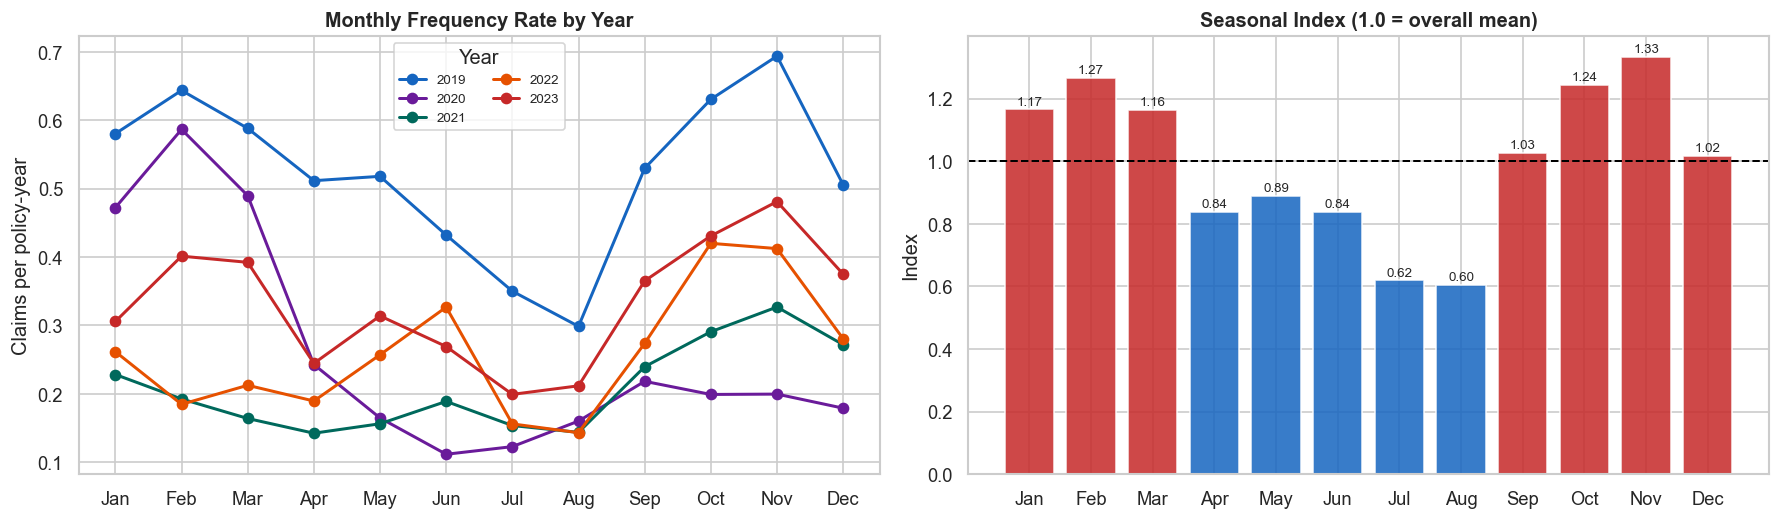

Month,Rate,Index
Jan,0.370,1.17
Feb,0.402,1.27
Mar,0.369,1.16
Apr,0.266,0.84
May,0.282,0.89
Jun,0.266,0.84
Jul,0.196,0.62
Aug,0.191,0.60
Sep,0.325,1.03
Oct,0.394,1.24


'tables\\sec3_seasonal_index.tex'

In [223]:
monthly = (daily.groupby(['Year', 'Month'], as_index=False)
                .agg(Consultations=('Consultations', 'sum'),
                     Exposure=('Exposure',       'sum')))
monthly['Rate'] = monthly['Consultations'] / monthly['Exposure']

seasonal = monthly.groupby('Month', as_index=False)['Rate'].mean()
seasonal['Index'] = seasonal['Rate'] / seasonal['Rate'].mean()
seasonal['MonthName'] = seasonal['Month'].map(lambda m: MONTH_NAMES[m - 1])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for yr in sorted(monthly['Year'].unique()):
    sub = monthly[monthly['Year'] == yr]
    axes[0].plot(sub['Month'], sub['Rate'], marker='o', lw=1.8,
                 color=YEAR_COLORS.get(yr), label=str(yr))
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(MONTH_NAMES)
axes[0].set_title('Monthly Frequency Rate by Year', fontweight='bold')
axes[0].set_ylabel('Claims per policy-year')
axes[0].legend(title='Year', ncol=2, fontsize=8)

colors_idx = ['#C62828' if v > 1 else '#1565C0' for v in seasonal['Index']]
axes[1].bar(seasonal['Month'], seasonal['Index'],
            color=colors_idx, edgecolor='white', alpha=0.85)
axes[1].axhline(1.0, color='black', lw=1.2, ls='--')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(MONTH_NAMES)
axes[1].set_title('Seasonal Index (1.0 = overall mean)', fontweight='bold')
axes[1].set_ylabel('Index')
for _, row in seasonal.iterrows():
    axes[1].text(row['Month'], row['Index'] + 0.015,
                 f"{row['Index']:.2f}", ha='center', fontsize=8)

plt.tight_layout()
save_fig(fig, 'sec3_monthly_trends')
plt.show()

seasonal_table = seasonal[['MonthName', 'Rate', 'Index']].rename(
    columns={'MonthName':'Month'})
fmt_seasonal = {'Rate': '{:.3f}', 'Index': '{:.2f}'}
display(style_centered(seasonal_table, fmt_seasonal))
save_table_tex(seasonal_table, 'sec3_seasonal_index',
               formats=fmt_seasonal,
               caption='Monthly seasonal index (1.00 = overall mean).',
               label='tab:sec3_seasonal_index')


### 3.2 Summer vs Winter

UAE-relevant season mapping (matches the Temperature Effect notebook):

| Season | Months | UAE characterisation |
|--------|--------|----------------------|
| Winter | Dec, Jan, Feb | Peak respiratory months; mild outdoor temperatures |
| Spring | Mar, Apr, May | Warming; school spring break in Mar-Apr |
| Summer | Jun, Jul, Aug, **Sep** | Extreme heat, school closures, expat outflow |
| Autumn | Oct, Nov     | Cooling, return-to-school surge |

*(September is grouped with Summer here because UAE summer extends into early autumn -- temperatures remain ≥ 35 °C.)*

**Kruskal-Wallis H-test** is non-parametric and works on daily rates without normality assumptions.


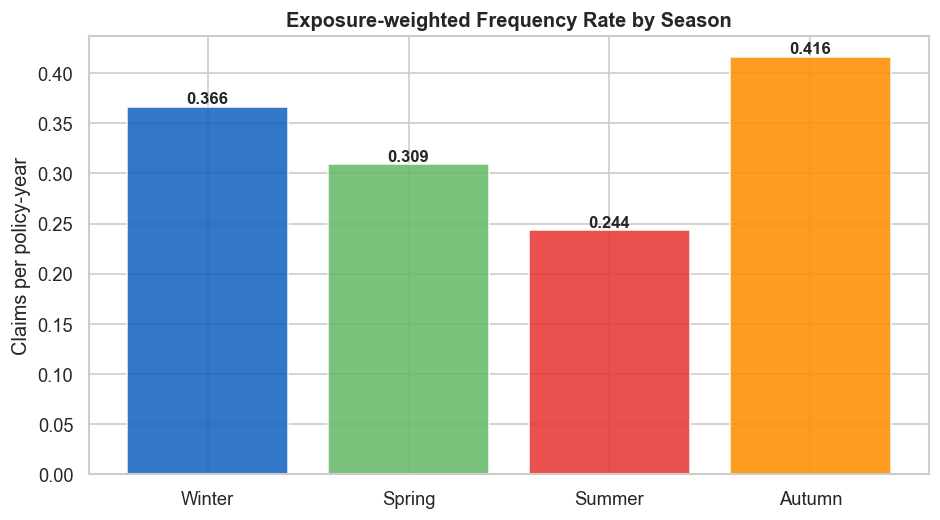

Kruskal-Wallis across 4 seasons: H = 242.0, p = 3.553e-52
Winter vs Summer (Mann-Whitney): U = 194188, p = 1.715e-30, Winter is +49.5% vs Summer


Season,Days,Consultations,Exposure,MeanDailyRate,Rate
Winter,451,"142,264","388,562",0.364,0.366
Spring,460,"118,061","381,650",0.306,0.309
Summer,610,"120,365","493,961",0.244,0.244
Autumn,305,"105,887","254,460",0.408,0.416


'tables\\sec3_seasons.tex'

In [224]:
SEASON_MAP = {12:'Winter', 1:'Winter', 2:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer', 9:'Summer',
              10:'Autumn', 11:'Autumn'}
SEASON_ORDER  = ['Winter', 'Spring', 'Summer', 'Autumn']
SEASON_COLORS = {'Winter':'#1565C0', 'Spring':'#66BB6A',
                 'Summer':'#E53935', 'Autumn':'#FF8F00'}

daily['Season'] = daily['Month'].map(SEASON_MAP)

season_stats = (daily.groupby('Season')
                     .agg(Days=('Date', 'nunique'),
                          Consultations=('Consultations', 'sum'),
                          Exposure=('Exposure', 'sum'),
                          MeanDailyRate=('Rate', 'mean'))
                     .reindex(SEASON_ORDER)
                     .reset_index())
season_stats['Rate'] = (season_stats['Consultations'] /
                        season_stats['Exposure'])

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [SEASON_COLORS[s] for s in season_stats['Season']]
ax.bar(season_stats['Season'], season_stats['Rate'],
       color=colors, edgecolor='white', alpha=0.88)
for i, row in season_stats.iterrows():
    ax.text(i, row['Rate'] * 1.01, f"{row['Rate']:.3f}",
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('Exposure-weighted Frequency Rate by Season', fontweight='bold')
ax.set_ylabel('Claims per policy-year')
plt.tight_layout()
save_fig(fig, 'sec3_seasons_bar')
plt.show()

groups = [daily.loc[daily['Season'] == s, 'Rate'].values for s in SEASON_ORDER]
h, p   = kruskal(*groups)
print(f'Kruskal-Wallis across 4 seasons: H = {h:.1f}, p = {p:.3e}')
winter_v = daily.loc[daily['Season'] == 'Winter', 'Rate'].values
summer_v = daily.loc[daily['Season'] == 'Summer', 'Rate'].values
u, p2    = mannwhitneyu(winter_v, summer_v, alternative='two-sided')
pct      = (winter_v.mean() - summer_v.mean()) / summer_v.mean() * 100
print(f'Winter vs Summer (Mann-Whitney): U = {u:.0f}, p = {p2:.3e}, Winter is {pct:+.1f}% vs Summer')

fmt_season = {
    'Days':          '{:,.0f}',
    'Consultations': '{:,.0f}',
    'Exposure':      '{:,.0f}',
    'MeanDailyRate': '{:.3f}',
    'Rate':          '{:.3f}',
}
display(style_centered(season_stats, fmt_season))
save_table_tex(season_stats, 'sec3_seasons',
               formats=fmt_season,
               caption='Exposure-weighted consultation rate by season.',
               label='tab:sec3_seasons')


### 3.3 Holiday vs Regular Months

UAE school-break months (matches the GLM_Advanced_Context notebook): **Mar, Apr, Jun, Jul, Aug, Dec, Jan**.

These months see lower in-school transmission and higher expat outflow in summer. Comparison uses Mann-Whitney U on daily rates.


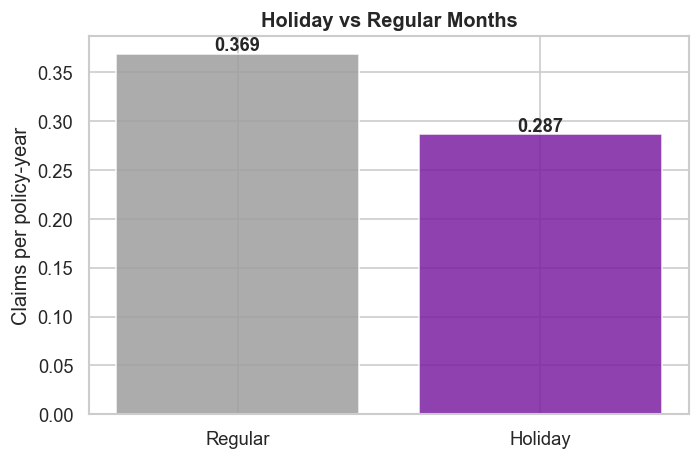

Mann-Whitney U = 289467, p = 7.034e-25
Holiday months are -22.3% vs Regular (daily-mean rate).


Holiday,Days,Consultations,Exposure,MeanDailyRate,Rate
Regular,751,"229,304","622,070",0.365,0.369
Holiday,"1,075","257,273","896,563",0.283,0.287


'tables\\sec3_holidays.tex'

In [225]:
HOLIDAY_MONTHS = {3, 4, 6, 7, 8, 12, 1}
daily['Holiday'] = np.where(daily['Month'].isin(HOLIDAY_MONTHS),
                            'Holiday', 'Regular')

hol_stats = (daily.groupby('Holiday')
                  .agg(Days=('Date', 'nunique'),
                       Consultations=('Consultations', 'sum'),
                       Exposure=('Exposure', 'sum'),
                       MeanDailyRate=('Rate', 'mean'))
                  .reindex(['Regular', 'Holiday'])
                  .reset_index())
hol_stats['Rate'] = hol_stats['Consultations'] / hol_stats['Exposure']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(hol_stats['Holiday'], hol_stats['Rate'],
       color=['#9E9E9E', '#7B1FA2'], edgecolor='white', alpha=0.85)
for i, row in hol_stats.iterrows():
    ax.text(i, row['Rate'] * 1.01, f"{row['Rate']:.3f}",
            ha='center', fontsize=11, fontweight='bold')
ax.set_title('Holiday vs Regular Months', fontweight='bold')
ax.set_ylabel('Claims per policy-year')
plt.tight_layout()
save_fig(fig, 'sec3_holidays_bar')
plt.show()

reg = daily.loc[daily['Holiday'] == 'Regular', 'Rate'].values
hol = daily.loc[daily['Holiday'] == 'Holiday', 'Rate'].values
u, p = mannwhitneyu(hol, reg, alternative='two-sided')
pct  = (hol.mean() - reg.mean()) / reg.mean() * 100
print(f'Mann-Whitney U = {u:.0f}, p = {p:.3e}')
print(f'Holiday months are {pct:+.1f}% vs Regular (daily-mean rate).')

fmt_hol = {
    'Days':          '{:,.0f}',
    'Consultations': '{:,.0f}',
    'Exposure':      '{:,.0f}',
    'MeanDailyRate': '{:.3f}',
    'Rate':          '{:.3f}',
}
display(style_centered(hol_stats, fmt_hol))
save_table_tex(hol_stats, 'sec3_holidays',
               formats=fmt_hol,
               caption='Consultation rate: holiday vs regular months.',
               label='tab:sec3_holidays')


### 3.4 Day of Week

The UAE work week ran **Sun-Thu** until 31 Dec 2021, then switched to **Mon-Fri** from 1 Jan 2022. Clinic operating hours follow the work week, so we expect:

- 2019-2021: high utilisation on Sun-Thu, low on Fri-Sat.
- 2022-2023: high on Mon-Fri, low on Sat-Sun.

We show the pattern pooled across years and separately for the two work-week regimes.


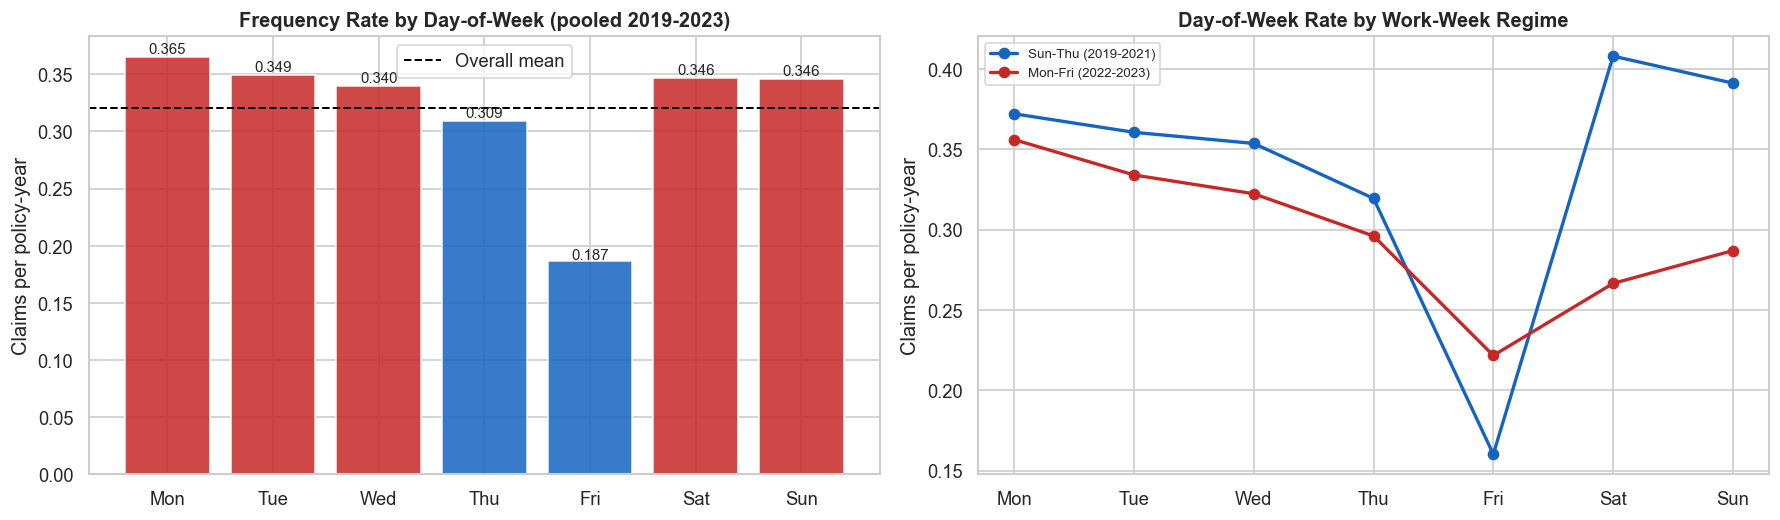

Day,MeanDailyConsults,Rate
Mon,304,0.365
Tue,291,0.349
Wed,283,0.340
Thu,257,0.309
Fri,155,0.187
Sat,288,0.346
Sun,288,0.346


'tables\\sec3_day_of_week.tex'

In [226]:
dow_stats = (daily.groupby('DOW')
                  .agg(Consultations=('Consultations', 'sum'),
                       Exposure=('Exposure', 'sum'),
                       MeanDailyConsults=('Consultations', 'mean'))
                  .reset_index())
dow_stats['Rate']    = dow_stats['Consultations'] / dow_stats['Exposure']
dow_stats['Day']     = dow_stats['DOW'].map(lambda d: DOW_NAMES[d])
dow_stats_disp = dow_stats[['Day', 'MeanDailyConsults', 'Rate']]

daily['WeekRegime'] = np.where(daily['Date'] < '2022-01-01',
                               'Sun-Thu (2019-2021)',
                               'Mon-Fri (2022-2023)')
regime_dow = (daily.groupby(['WeekRegime', 'DOW'])
                   .agg(c=('Consultations', 'sum'),
                        e=('Exposure',       'sum'))
                   .reset_index())
regime_dow['Rate'] = regime_dow['c'] / regime_dow['e']
regime_dow['Day']  = regime_dow['DOW'].map(lambda d: DOW_NAMES[d])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
mean_rate = dow_stats['Rate'].mean()
bar_c = ['#C62828' if v > mean_rate else '#1565C0' for v in dow_stats['Rate']]
axes[0].bar(dow_stats['Day'], dow_stats['Rate'],
            color=bar_c, edgecolor='white', alpha=0.85)
axes[0].axhline(mean_rate, color='black', lw=1.2, ls='--', label='Overall mean')
for i, row in dow_stats.iterrows():
    axes[0].text(i, row['Rate'] * 1.01, f"{row['Rate']:.3f}",
                 ha='center', fontsize=9)
axes[0].set_title('Frequency Rate by Day-of-Week (pooled 2019-2023)',
                  fontweight='bold')
axes[0].set_ylabel('Claims per policy-year')
axes[0].legend()

regimes = ['Sun-Thu (2019-2021)', 'Mon-Fri (2022-2023)']
rcolors = {'Sun-Thu (2019-2021)':'#1565C0', 'Mon-Fri (2022-2023)':'#C62828'}
for reg in regimes:
    sub = regime_dow[regime_dow['WeekRegime'] == reg].sort_values('DOW')
    axes[1].plot(sub['Day'], sub['Rate'], marker='o', lw=2,
                 color=rcolors[reg], label=reg)
axes[1].set_title('Day-of-Week Rate by Work-Week Regime', fontweight='bold')
axes[1].set_ylabel('Claims per policy-year')
axes[1].legend(fontsize=8)
plt.tight_layout()
save_fig(fig, 'sec3_dow_chart')
plt.show()

fmt_dow = {'MeanDailyConsults':'{:,.0f}', 'Rate':'{:.3f}'}
display(style_centered(dow_stats_disp, fmt_dow))
save_table_tex(dow_stats_disp, 'sec3_day_of_week',
               formats=fmt_dow,
               caption='Consultation rate by day of week (pooled 2019-2023).',
               label='tab:sec3_day_of_week')


### 3.5 Year × Month Heatmap

Single picture of the full series: rows are years, columns are months, colour is total consultations. Useful for spotting 2020's spring trough (lockdown) and the post-pandemic recovery.


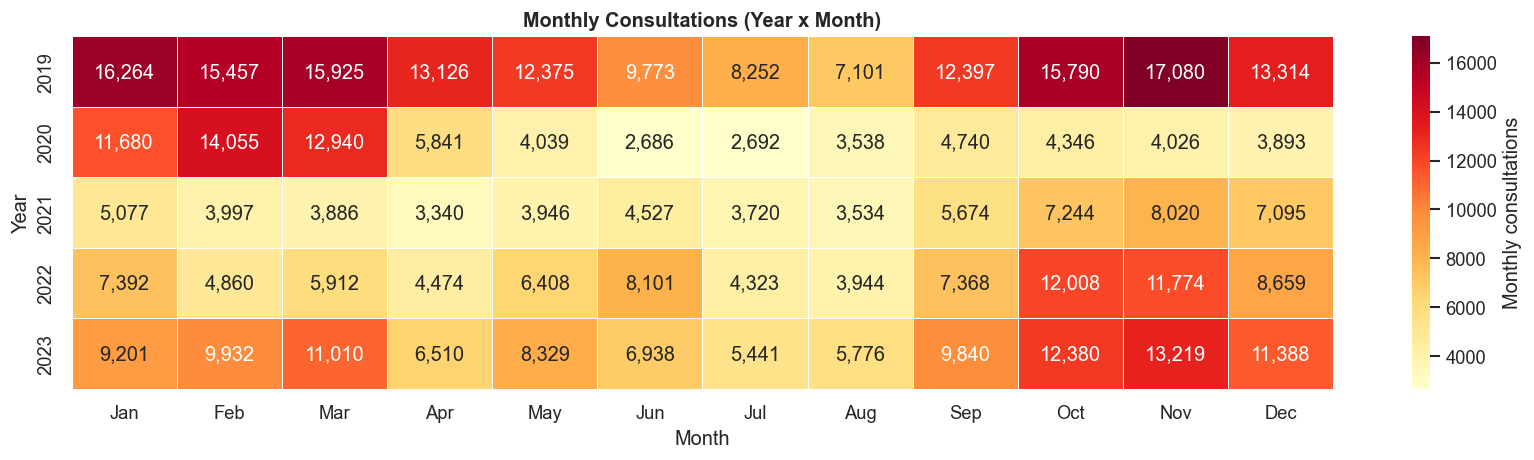

In [227]:
pivot = (monthly.pivot(index='Year', columns='Month', values='Consultations')
                .fillna(0))
pivot.columns = MONTH_NAMES

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Monthly consultations'})
ax.set_title('Monthly Consultations (Year x Month)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
save_fig(fig, 'sec3_year_month_heatmap')
plt.show()


## 4. COVID Impact

Four sub-questions, each lifted directly from the structure used in `GLM_Advanced_Context.ipynb` and `GLM_NB_Predictor.ipynb`:

1. **Phase segmentation** -- six phases driven entirely by date (no behavioural inference).
2. **Frequency rate by phase** -- exposure-weighted, with daily-mean error bars.
3. **Statistical tests** -- Pre-COVID vs each later phase via Mann-Whitney U on daily rates.
4. **Mask mandate effect** -- separate from phase, using the 2020-03-26 to 2022-09-19 window.

All segmentations are derived from `daily['Date']`, so this section is self-contained.


### 4.1 Phase Segmentation

| Phase | Start | Why this boundary |
|-------|-------|-------------------|
| Pre-COVID | 2019-01-01 | Pre-pandemic baseline |
| Lockdown | 2020-03-01 | UAE imposed movement restrictions |
| Reopening Ph1 | 2020-05-27 | Initial reopening of non-essential businesses |
| Recovery | 2020-07-15 | Broader reopening, schools partially open |
| Vaccine Drive | 2020-12-14 | First vaccines administered in UAE |
| Post-COVID | 2022-01-01 | Mandates relaxed; treat 2022-2023 as a new baseline |


In [228]:
PHASE_EDGES = pd.to_datetime([
    '2019-01-01', '2020-03-01', '2020-05-27', '2020-07-15',
    '2020-12-14', '2022-01-01', '2024-01-01',
])
PHASE_LABELS = ['Pre-COVID', 'Lockdown', 'Reopening Ph1',
                'Recovery', 'Vaccine Drive', 'Post-COVID']
PHASE_COLORS = {
    'Pre-COVID':    '#1565C0', 'Lockdown':      '#B71C1C',
    'Reopening Ph1':'#FF8F00', 'Recovery':      '#F9A825',
    'Vaccine Drive':'#2E7D32', 'Post-COVID':    '#00838F',
}

daily['Phase'] = pd.cut(daily['Date'], bins=PHASE_EDGES,
                        labels=PHASE_LABELS, right=False).astype(str)

phase_days = (daily.groupby('Phase')
                   .agg(Days=('Date', 'nunique'),
                        FirstDay=('Date', 'min'),
                        LastDay=('Date',  'max'))
                   .reindex(PHASE_LABELS)
                   .reset_index())
phase_days['FirstDay'] = phase_days['FirstDay'].dt.strftime('%Y-%m-%d')
phase_days['LastDay']  = phase_days['LastDay'].dt.strftime('%Y-%m-%d')

fmt_pd = {'Days': '{:,.0f}'}
display(style_centered(phase_days, fmt_pd))
save_table_tex(phase_days, 'sec4_phase_segmentation',
               formats=fmt_pd,
               caption='COVID phase date ranges and day counts.',
               label='tab:sec4_phase_segmentation')


Phase,Days,FirstDay,LastDay
Pre-COVID,425,2019-01-01,2020-02-29
Lockdown,87,2020-03-01,2020-05-26
Reopening Ph1,49,2020-05-27,2020-07-14
Recovery,152,2020-07-15,2020-12-13
Vaccine Drive,383,2020-12-14,2021-12-31
Post-COVID,730,2022-01-01,2023-12-31


'tables\\sec4_phase_segmentation.tex'

### 4.2 Frequency Rate by Phase

Bars show the **exposure-weighted** rate per phase (total consultations divided by total policy-years in the phase). Error bars are the 95% CI of the daily-mean rate (± 1.96 × SE), which captures day-to-day volatility within the phase.


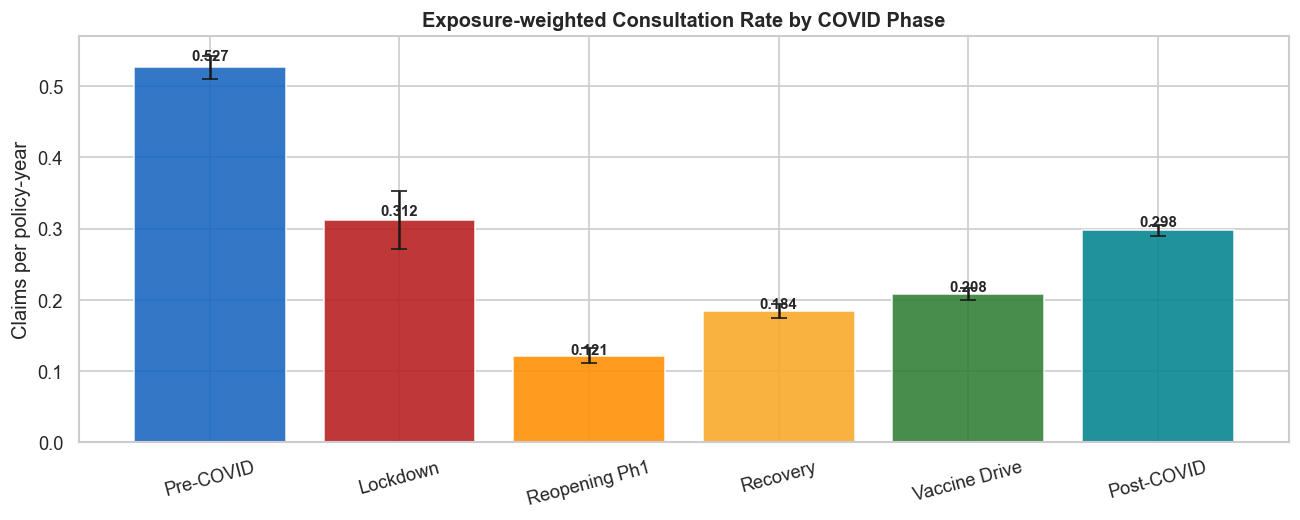

Phase,Days,Consultations,Exposure,Rate,MeanDailyRate,CI95
Pre-COVID,425,"182,589","346,675",0.527,0.523,0.0166
Lockdown,87,"22,189","71,029",0.312,0.308,0.0405
Reopening Ph1,49,"4,607","37,972",0.121,0.122,0.0108
Recovery,152,"19,612","106,668",0.184,0.184,0.0099
Vaccine Drive,383,"62,393","300,380",0.208,0.207,0.0086
Post-COVID,730,"195,187","655,910",0.298,0.296,0.0081


'tables\\sec4_phase_rates.tex'

In [229]:
phase_stats = (daily.groupby('Phase')
                    .agg(Days=('Date', 'nunique'),
                         Consultations=('Consultations', 'sum'),
                         Exposure=('Exposure',       'sum'),
                         MeanDailyRate=('Rate', 'mean'),
                         SemDailyRate=('Rate', 'sem'))
                    .reindex(PHASE_LABELS)
                    .reset_index())
phase_stats['Rate'] = phase_stats['Consultations'] / phase_stats['Exposure']
phase_stats['CI95'] = phase_stats['SemDailyRate'] * 1.96

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = [PHASE_COLORS[p] for p in phase_stats['Phase']]
ax.bar(phase_stats['Phase'], phase_stats['Rate'],
       yerr=phase_stats['CI95'], capsize=5,
       color=colors, edgecolor='white', alpha=0.88)
for i, row in phase_stats.iterrows():
    ax.text(i, row['Rate'] * 1.02, f"{row['Rate']:.3f}",
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('Exposure-weighted Consultation Rate by COVID Phase',
             fontweight='bold')
ax.set_ylabel('Claims per policy-year')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
save_fig(fig, 'sec4_phase_rates_bar')
plt.show()

phase_table = phase_stats[['Phase', 'Days', 'Consultations', 'Exposure',
                            'Rate', 'MeanDailyRate', 'CI95']]
fmt_phase = {
    'Days':          '{:,.0f}',
    'Consultations': '{:,.0f}',
    'Exposure':      '{:,.0f}',
    'Rate':          '{:.3f}',
    'MeanDailyRate': '{:.3f}',
    'CI95':          '{:.4f}',
}
display(style_centered(phase_table, fmt_phase))
save_table_tex(phase_table, 'sec4_phase_rates',
               formats=fmt_phase,
               caption='Consultation rate by COVID phase with 95% CI.',
               label='tab:sec4_phase_rates')


### 4.3 Statistical Tests

**Kruskal-Wallis** tests whether any phase differs (omnibus). **Mann-Whitney U** compares each later phase against the Pre-COVID baseline; reported with the percentage change in mean daily rate.

Non-parametric tests are appropriate here because daily-rate distributions are skewed and have heavy tails (lockdown days are extreme outliers under any normality assumption).


In [230]:
groups = [daily.loc[daily['Phase'] == p, 'Rate'].values for p in PHASE_LABELS]
h, p   = kruskal(*groups)
print(f'Kruskal-Wallis across 6 phases: H = {h:.1f}, p = {p:.3e}')

pre  = daily.loc[daily['Phase'] == 'Pre-COVID', 'Rate'].values
rows = []
for phase in PHASE_LABELS[1:]:
    other = daily.loc[daily['Phase'] == phase, 'Rate'].values
    u, p2 = mannwhitneyu(pre, other, alternative='two-sided')
    pct   = (other.mean() - pre.mean()) / pre.mean() * 100
    sig   = '***' if p2 < 0.001 else ('**' if p2 < 0.01 else
            ('*' if p2 < 0.05 else 'ns'))
    rows.append({
        'Comparison':   f'Pre-COVID vs {phase}',
        'U':            u,
        'p_value':      p2,
        'pct_change':   pct,
        'significance': sig,
    })
tests = pd.DataFrame(rows)

fmt_tests = {
    'U':          '{:,.0f}',
    'p_value':    '{:.2e}',
    'pct_change': '{:+.1f}%',
}
display(style_centered(tests, fmt_tests))
save_table_tex(tests, 'sec4_phase_tests',
               formats=fmt_tests,
               caption='Pre-COVID vs each later phase (Mann-Whitney U).',
               label='tab:sec4_phase_tests')


Kruskal-Wallis across 6 phases: H = 814.2, p = 9.679e-174


Comparison,U,p_value,pct_change,significance
Pre-COVID vs Lockdown,"29,560",1.29e-18,-41.2%,***
Pre-COVID vs Reopening Ph1,"20,710",8.19e-30,-76.8%,***
Pre-COVID vs Recovery,"62,322",5.90e-65,-64.9%,***
Pre-COVID vs Vaccine Drive,"152,765",5.69e-103,-60.5%,***
Pre-COVID vs Post-COVID,"263,865",4.93e-88,-43.4%,***


'tables\\sec4_phase_tests.tex'

### 4.4 Mask Mandate Effect

UAE mandatory mask period: **2020-03-26 to 2022-09-19**. This window heavily overlaps COVID phases 2-5, so the raw mandate-vs-no-mandate comparison reflects both the mask effect *and* the surrounding behavioural shifts. Treat the figure as descriptive; the GLM in later notebooks separates the two.


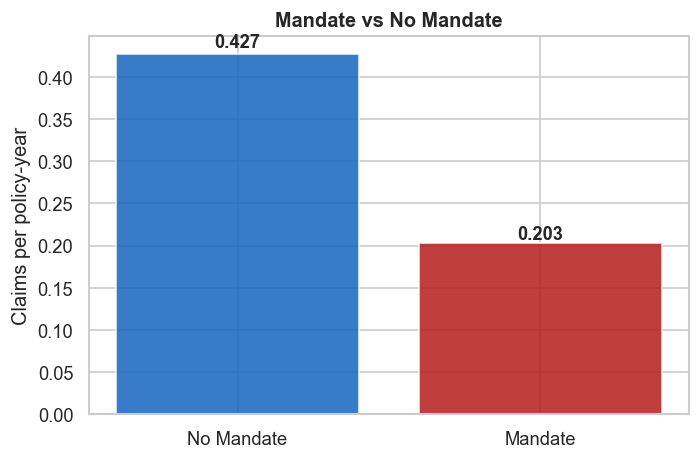

Mann-Whitney U = 87206, p = 3.888e-188
Mandate days are -53.0% vs No-Mandate days (daily-mean rate).
CAVEAT: confounded with COVID phase. The GLM in later notebooks separates the two effects.


Mask,Days,Consultations,Exposure,MeanDailyRate,Rate
No Mandate,918,"339,845","795,968",0.430,0.427
Mandate,908,"146,732","722,665",0.202,0.203


'tables\\sec4_mask.tex'

In [231]:
MASK_START = pd.Timestamp('2020-03-26')
MASK_END   = pd.Timestamp('2022-09-19')

daily['Mask'] = np.where(
    (daily['Date'] >= MASK_START) & (daily['Date'] <= MASK_END),
    'Mandate', 'No Mandate')

mask_stats = (daily.groupby('Mask')
                   .agg(Days=('Date', 'nunique'),
                        Consultations=('Consultations', 'sum'),
                        Exposure=('Exposure', 'sum'),
                        MeanDailyRate=('Rate', 'mean'))
                   .reindex(['No Mandate', 'Mandate'])
                   .reset_index())
mask_stats['Rate'] = mask_stats['Consultations'] / mask_stats['Exposure']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(mask_stats['Mask'], mask_stats['Rate'],
       color=['#1565C0', '#B71C1C'], edgecolor='white', alpha=0.85)
for i, row in mask_stats.iterrows():
    ax.text(i, row['Rate'] * 1.02, f"{row['Rate']:.3f}",
            ha='center', fontsize=11, fontweight='bold')
ax.set_title('Mandate vs No Mandate', fontweight='bold')
ax.set_ylabel('Claims per policy-year')
plt.tight_layout()
save_fig(fig, 'sec4_mask_bar')
plt.show()

on  = daily.loc[daily['Mask'] == 'Mandate',    'Rate'].values
off = daily.loc[daily['Mask'] == 'No Mandate', 'Rate'].values
u, p = mannwhitneyu(on, off, alternative='two-sided')
pct  = (on.mean() - off.mean()) / off.mean() * 100
print(f'Mann-Whitney U = {u:.0f}, p = {p:.3e}')
print(f'Mandate days are {pct:+.1f}% vs No-Mandate days (daily-mean rate).')
print('CAVEAT: confounded with COVID phase. The GLM in later notebooks separates the two effects.')

fmt_mask = {
    'Days':          '{:,.0f}',
    'Consultations': '{:,.0f}',
    'Exposure':      '{:,.0f}',
    'MeanDailyRate': '{:.3f}',
    'Rate':          '{:.3f}',
}
display(style_centered(mask_stats, fmt_mask))
save_table_tex(mask_stats, 'sec4_mask',
               formats=fmt_mask,
               caption='Consultation rate: mask mandate vs no mandate.',
               label='tab:sec4_mask')


### 4.5 Timeline Visualisation

Daily consultations with a 28-day rolling mean, overlaid with shaded COVID-phase bands and the mask-mandate window. This is the single figure that links every quantitative finding above back to the calendar.


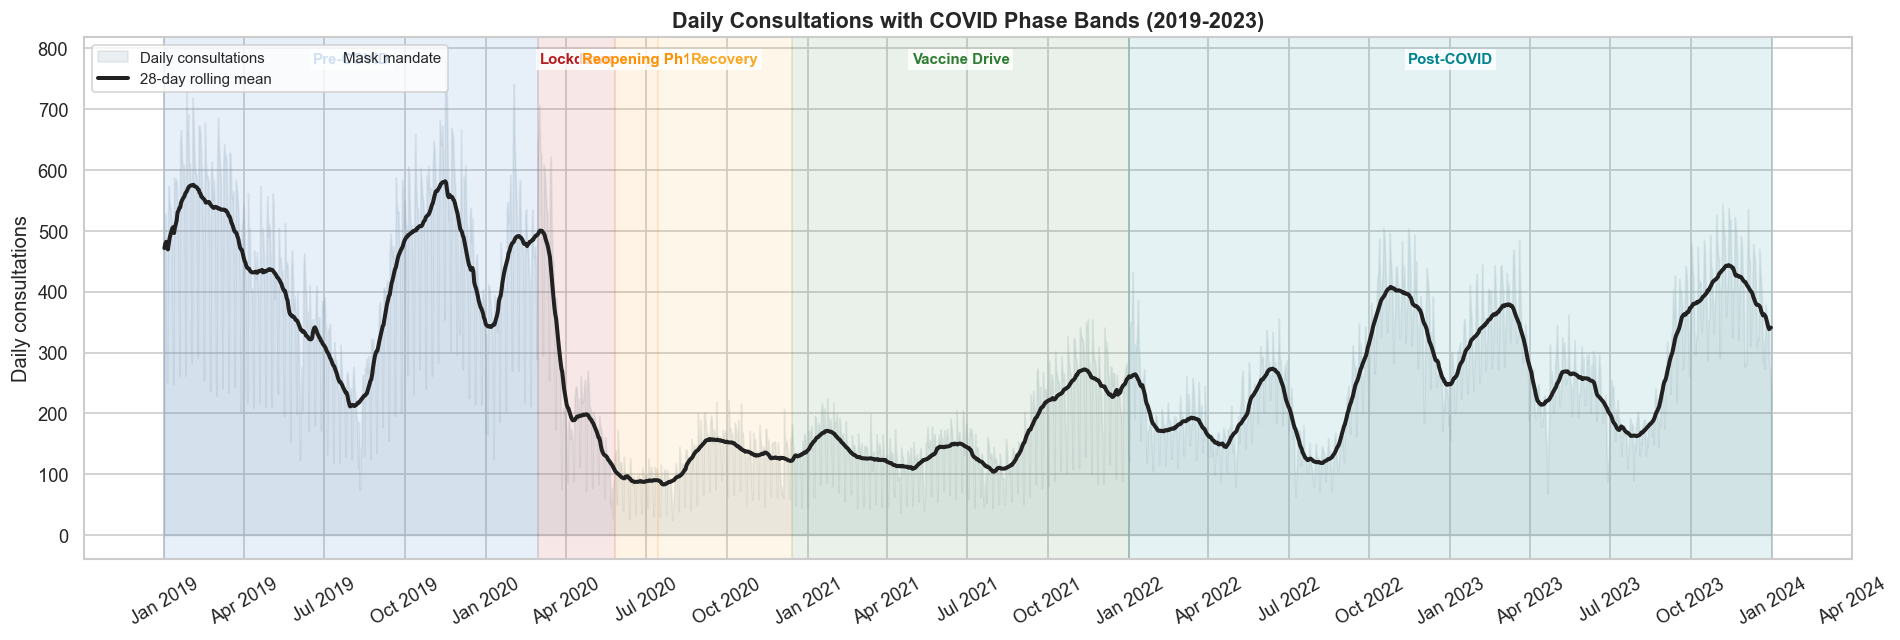

In [232]:
ts = daily.sort_values('Date').copy()
ts['Roll28'] = ts['Consultations'].rolling(28, center=True, min_periods=14).mean()

fig, ax = plt.subplots(figsize=(16, 5.5))
ax.fill_between(ts['Date'], ts['Consultations'], alpha=0.18, color='#90A4AE',
                label='Daily consultations')
ax.plot(ts['Date'], ts['Roll28'], lw=2.4, color='#212121',
        label='28-day rolling mean')

for i in range(len(PHASE_LABELS)):
    start, end = PHASE_EDGES[i], PHASE_EDGES[i + 1]
    ax.axvspan(start, end, alpha=0.10, color=PHASE_COLORS[PHASE_LABELS[i]])
    mid = start + (end - start) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.97, PHASE_LABELS[i],
            ha='center', va='top', fontsize=9, fontweight='bold',
            color=PHASE_COLORS[PHASE_LABELS[i]],
            bbox=dict(fc='white', alpha=0.8, pad=2, ec='none'))

ax.axvspan(MASK_START, MASK_END, alpha=0.0, hatch='///', edgecolor='black',
           lw=0, label='Mask mandate')

ax.set_title('Daily Consultations with COVID Phase Bands (2019-2023)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Daily consultations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.legend(loc='upper left', ncol=2, fontsize=9)
plt.tight_layout()
save_fig(fig, 'sec4_covid_timeline')
plt.show()


## 5. Model Selection: Poisson vs Negative Binomial

Daily claim counts are almost always overdispersed -- `Var(Y) > E[Y]` because of clustering effects (flu spikes, weekday/weekend cycles, COVID phases). Poisson assumes `Var(Y) = mu`, which gives standard errors that are too small. Negative Binomial generalises with a dispersion parameter `alpha`:

$$\mathrm{Var}(Y) = \mu + \alpha \mu^2$$

When `alpha -> 0`, NB collapses to Poisson. We:

1. Build a model frame (one row per Date x demographics) with all features encoded as categoricals.
2. Fit a Poisson GLM, then estimate `alpha` by method of moments from its Pearson residuals.
3. Refit with NB using that `alpha`.
4. Compare AIC, Pseudo R^2, Pearson/df, residual diagnostics.


### 5.1 Build the Model Frame

Predictors (categorical): `AgeBand`, `Gender`, `Nationality`, `Dependency`, `Month`, `DOW`, `Holiday`, `Phase`, `Mask`. `Year` is deliberately excluded because COVID `Phase` already absorbs the year-level effect (collinear) -- this matches `GLM_NB_Predictor.ipynb`.

Offset: `LogExposure`. Target: `Consultations`.


In [233]:
import gc
import statsmodels.api as sm
import statsmodels.formula.api as smf

PREDICTORS = ['AgeBand', 'Gender', 'Nationality', 'Dependency',
              'Year', 'Month', 'DOW', 'Holiday', 'Phase', 'Mask']

# 1) Full-grain frame -- one row per (Date x demographics). Used in section 7
#    for actual-vs-predicted plots; never passed to a GLM solver.
model_df = panel.copy()
model_df['Year']    = model_df['Date'].dt.year
model_df['Month']   = model_df['Date'].dt.month
model_df['DOW']     = model_df['Date'].dt.dayofweek
model_df['Holiday'] = np.where(model_df['Month'].isin(HOLIDAY_MONTHS),
                               'Holiday', 'Regular')
model_df['Phase']   = pd.cut(model_df['Date'], bins=PHASE_EDGES,
                             labels=PHASE_LABELS, right=False).astype(str)
model_df['Mask']    = np.where(
    (model_df['Date'] >= MASK_START) & (model_df['Date'] <= MASK_END),
    'Mandate', 'No Mandate')

# 2) Predictor-grain frame -- one row per unique combination of the
#    PREDICTORS, with summed Consultations and Exposure.
#    Poisson/NB with offset(log(Exposure)) gives the SAME MLE on this
#    aggregated frame as on the full-grain frame, but with O(10x) less RAM.
fit_df = (model_df.groupby(PREDICTORS, observed=True)
                  .agg(Consultations=('Consultations', 'sum'),
                       Exposure=('Exposure',       'sum'))
                  .reset_index())
fit_df = fit_df[fit_df['Exposure'] >= MIN_EXPOSURE].reset_index(drop=True)
fit_df['LogExposure'] = np.log(fit_df['Exposure']).clip(lower=-10)

for col in PREDICTORS:
    fit_df[col]   = fit_df[col].astype('category')
    model_df[col] = model_df[col].astype('category')

FULL_FORMULA = ('Consultations ~ C(AgeBand) + C(Gender) + C(Nationality) + '
                'C(Dependency) + C(Month) + C(DOW) + C(Holiday) + '
                'C(Phase, Treatment(reference="Pre-COVID")) + '
                'C(Mask,  Treatment(reference="No Mandate"))')

gc.collect()
print(f'model_df (full grain) : {len(model_df):,} rows')
print(f'fit_df   (fit grain)  : {len(fit_df):,} rows  '
      f'({len(model_df)/len(fit_df):.1f}x smaller)')
print(f'Exposure check        : model_df={model_df["Exposure"].sum():,.0f}, '
      f'fit_df={fit_df["Exposure"].sum():,.0f}')
print(f'Consults check        : model_df={int(model_df["Consultations"].sum()):,}, '
      f'fit_df={int(fit_df["Consultations"].sum()):,}')
print(f'Formula               :  {FULL_FORMULA}')


model_df (full grain) : 659,396 rows
fit_df   (fit grain)  : 163,795 rows  (4.0x smaller)
Exposure check        : model_df=1,518,633, fit_df=1,518,633
Consults check        : model_df=486,577, fit_df=486,577
Formula               :  Consultations ~ C(AgeBand) + C(Gender) + C(Nationality) + C(Dependency) + C(Month) + C(DOW) + C(Holiday) + C(Phase, Treatment(reference="Pre-COVID")) + C(Mask,  Treatment(reference="No Mandate"))


### 5.2 Fit Poisson, Estimate Alpha, Refit Negative Binomial

IRLS can fail on high-cardinality designs; we fall back to BFGS automatically (matches `GLM_NB_Predictor`). This cell takes a minute or two on the full panel.


In [234]:
def glm_fit_with_fallback(formula, data, family, offset):
    try:
        return smf.glm(formula, data=data, family=family,
                       offset=offset).fit(maxiter=200)
    except (ValueError, np.linalg.LinAlgError, MemoryError) as e:
        print(f'  IRLS failed ({type(e).__name__}); retrying with BFGS...')
        return smf.glm(formula, data=data, family=family,
                       offset=offset).fit(method='bfgs', maxiter=500)


print('Step 1 -- Poisson pre-fit (on fit_df)...')
glm_poisson = glm_fit_with_fallback(
    FULL_FORMULA, fit_df, sm.families.Poisson(), fit_df['LogExposure'])
print(f'  Poisson AIC         : {glm_poisson.aic:,.1f}')
print(f'  Poisson Pearson/df  : {glm_poisson.pearson_chi2 / glm_poisson.df_resid:.3f}')

print('\nStep 2 -- Estimate NB alpha by method of moments...')
mu_p_fit = glm_poisson.predict(fit_df, offset=fit_df['LogExposure']).values
y_fit    = fit_df['Consultations'].values
alpha_hat = max(((y_fit - mu_p_fit)**2 - mu_p_fit).sum() / (mu_p_fit**2).sum(), 1e-6)
print(f'  alpha_hat = {alpha_hat:.4f}')

print('\nStep 3 -- NB fit (on fit_df) with that alpha...')
glm_nb = glm_fit_with_fallback(
    FULL_FORMULA, fit_df,
    sm.families.NegativeBinomial(alpha=alpha_hat),
    fit_df['LogExposure'])
print(f'  NB AIC              : {glm_nb.aic:,.1f}')
print(f'  NB Pearson/df       : {glm_nb.pearson_chi2 / glm_nb.df_resid:.3f}')

print('\nStep 4 -- Project predicted rate back to model_df via merge...')
fit_df['mu_p']  = mu_p_fit
fit_df['mu_nb'] = glm_nb.predict(fit_df, offset=fit_df['LogExposure']).values
fit_df['Rate_P']  = fit_df['mu_p']  / fit_df['Exposure']
fit_df['Rate_NB'] = fit_df['mu_nb'] / fit_df['Exposure']

model_df = model_df.merge(fit_df[PREDICTORS + ['Rate_P', 'Rate_NB']],
                          on=PREDICTORS, how='left')
model_df['Predicted_P']  = model_df['Rate_P']  * model_df['Exposure']
model_df['Predicted_NB'] = model_df['Rate_NB'] * model_df['Exposure']
# Default 'Predicted' alias points to NB (used by section 7)
model_df['Predicted']    = model_df['Predicted_NB']

missing = model_df['Predicted'].isna().sum()
print(f'  rows in model_df with no NB prediction (unmatched predictor combo): {missing:,}')
print(f'  total predicted (NB) : {model_df["Predicted"].sum():,.0f}')
print(f'  total actual         : {model_df["Consultations"].sum():,.0f}')

gc.collect()


Step 1 -- Poisson pre-fit (on fit_df)...
  Poisson AIC         : 345,444.0
  Poisson Pearson/df  : 1.507

Step 2 -- Estimate NB alpha by method of moments...
  alpha_hat = 0.1110

Step 3 -- NB fit (on fit_df) with that alpha...
  NB AIC              : 308,245.9
  NB Pearson/df       : 1.094

Step 4 -- Project predicted rate back to model_df via merge...
  rows in model_df with no NB prediction (unmatched predictor combo): 0
  total predicted (NB) : 499,420
  total actual         : 486,577


800

### 5.3 Side-by-side Comparison

**AIC** -- lower is better; differences > 10 are decisive.

**Pearson / df** -- should be ~1.0 for a well-specified model. Poisson values much greater than 1 are the smoking gun of overdispersion.

**Pseudo R^2** -- McFadden style, `1 - deviance/null_deviance`. Comparable within a family.


Model,AIC,PseudoR2,DevianceDf,PearsonDf,LogLik,dAIC,Verdict
Poisson,"345,444",0.5811,1.041,1.507,"-172,677","37,198",
NegBin,"308,246",0.4216,0.650,1.094,"-154,078",0,preferred


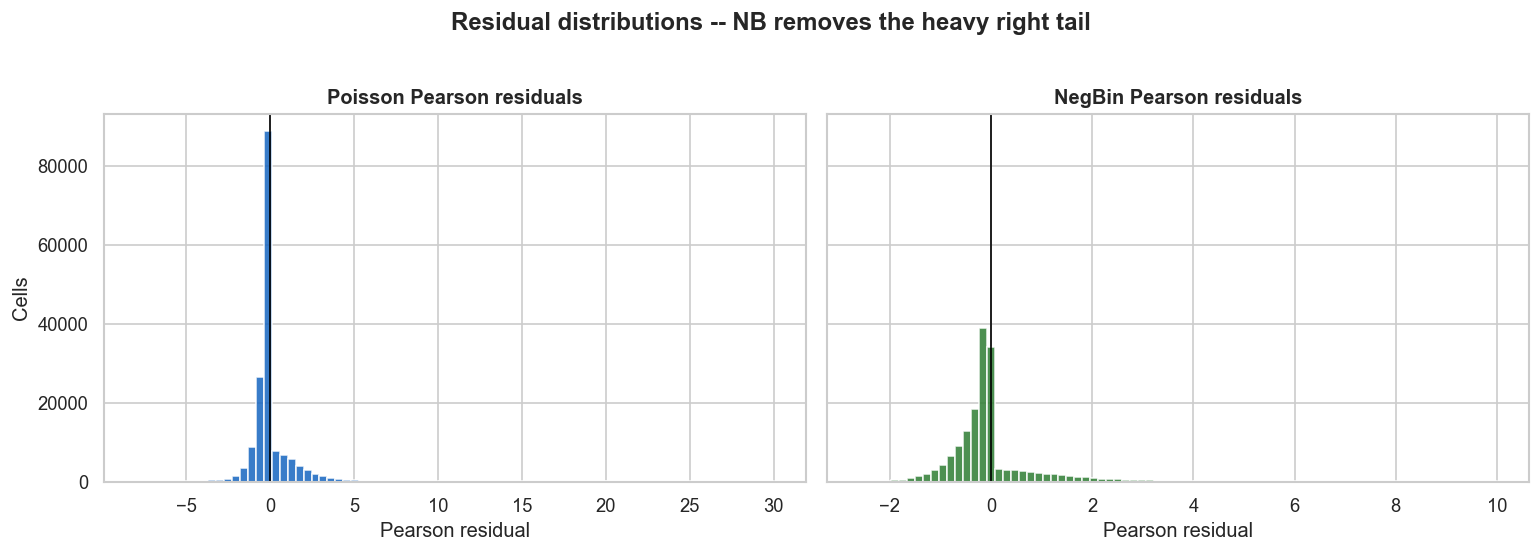

Winner: NegBin  (delta-AIC = 37,198)


In [235]:
def model_metrics(name, m):
    return {
        'Model':       name,
        'AIC':         m.aic,
        'PseudoR2':    1 - m.deviance / m.null_deviance,
        'DevianceDf':  m.deviance      / m.df_resid,
        'PearsonDf':   m.pearson_chi2  / m.df_resid,
        'LogLik':      m.llf,
    }

cmp_df = pd.DataFrame([
    model_metrics('Poisson', glm_poisson),
    model_metrics('NegBin',  glm_nb),
])
cmp_df['dAIC']    = cmp_df['AIC'] - cmp_df['AIC'].min()
cmp_df['Verdict'] = np.where(cmp_df['AIC'] == cmp_df['AIC'].min(),
                             'preferred', '')

fmt_cmp = {
    'AIC':        '{:,.0f}',
    'PseudoR2':   '{:.4f}',
    'DevianceDf': '{:.3f}',
    'PearsonDf':  '{:.3f}',
    'LogLik':     '{:,.0f}',
    'dAIC':       '{:,.0f}',
}
display(style_centered(cmp_df, fmt_cmp))
save_table_tex(cmp_df, 'sec5_poisson_vs_nb',
               formats=fmt_cmp,
               caption='Poisson vs Negative Binomial GLM (same formula, same offset).',
               label='tab:sec5_poisson_vs_nb')

# Residual diagnostic at fit_df grain (the grain at which the model was fit)
y_fit_arr = fit_df['Consultations'].values
res_p  = ((y_fit_arr - fit_df['mu_p'].values)  /
          np.sqrt(fit_df['mu_p'].values  + 1e-9))
res_nb = ((y_fit_arr - fit_df['mu_nb'].values) /
          np.sqrt(fit_df['mu_nb'].values + alpha_hat * fit_df['mu_nb'].values**2 + 1e-9))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
axes[0].hist(np.clip(res_p, -10, 30), bins=80, color='#1565C0',
             edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('Poisson Pearson residuals', fontweight='bold')
axes[0].set_xlabel('Pearson residual')
axes[0].set_ylabel('Cells')

axes[1].hist(np.clip(res_nb, -10, 10), bins=80, color='#2E7D32',
             edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('NegBin Pearson residuals', fontweight='bold')
axes[1].set_xlabel('Pearson residual')

plt.suptitle('Residual distributions -- NB removes the heavy right tail',
             fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'sec5_residuals')
plt.show()

winner = 'NegBin' if glm_nb.aic < glm_poisson.aic else 'Poisson'
delta  = abs(glm_nb.aic - glm_poisson.aic)
print(f'Winner: {winner}  (delta-AIC = {delta:,.0f})')


### 5.4 Recompute Bookkeeping at the Unaggregated Grain

**Why** -- the fit in 5.2 used `fit_df` (rows = unique predictor combos), which made the design matrix small enough to invert. Poisson and NB GLMs admit a sufficient statistic: within a combo, only `(sum y, sum e)` matters, so the MLE of β on the aggregated frame is **identical** to what you'd get on the full grain. We pay no statistical cost for the coefficients.

But two reported numbers *are* grain-dependent:

1. **`alpha_hat`**. Method of moments solves `Var(Y) = mu + alpha * mu^2`. Summing K independent NB variables gives `Var(Y_agg) = mu_agg + (alpha / K) * mu_agg^2`, so the same estimator on aggregated counts returns `alpha / K`. The aggregated value is mechanically too small; it is not the dispersion of the daily process.
2. **AIC**. The log-likelihood includes the data-dependent terms `y log(e)` and `-log(y!)` which shift when rows are collapsed. The MLE point is unchanged, but the absolute likelihood value, and therefore AIC, is not comparable across row representations.

**Fix (zero refit cost):**

1. We already have `Predicted_P` and `Predicted_NB` on `model_df` (full grain) from the rate-merge in §5.2 -- no `glm.predict()` call on the big frame.
2. Recompute `alpha_hat` by method of moments using the **Poisson** `mu` at the full grain (matches `GLM_NB_Predictor`).
3. Recompute Poisson and NB log-likelihoods on the full-grain `y, mu`, then AIC, Pearson/df, and Pseudo R².

The output table below shows aggregated-grain numbers next to full-grain numbers. The latter are the ones to quote in the paper -- they describe the daily-cell-level model.


In [236]:
from scipy.special import gammaln

y_full  = model_df['Consultations'].values.astype(float)
mu_p    = model_df['Predicted_P'].values
mu_nb_v = model_df['Predicted_NB'].values
n_full  = len(y_full)

# --- Re-estimate alpha at the full grain (Poisson MoM, matches prior work) ---
alpha_full = max(((y_full - mu_p)**2 - mu_p).sum() / (mu_p**2).sum(), 1e-6)
print(f'alpha_hat at full grain (matches GLM_NB_Predictor convention): {alpha_full:.4f}')
print(f'alpha_hat at aggregated grain (already reported)              : {alpha_hat:.4f}')
print(f'ratio (full / aggregated)                                     : {alpha_full / alpha_hat:.1f}x')

# Helper -- numerically safe log
def _safe_log(x):
    return np.log(np.maximum(x, 1e-300))

# --- Poisson log-likelihood at full grain ---
ll_p = (y_full * _safe_log(mu_p) - mu_p - gammaln(y_full + 1)).sum()
k_p  = int(glm_poisson.df_model) + 1                       # parameters incl. intercept
aic_p_full = 2 * k_p - 2 * ll_p
pearson_p  = ((y_full - mu_p)**2 / np.maximum(mu_p, 1e-9)).sum()
# Saturated Poisson log-likelihood (mu_i = y_i)
ll_p_sat = (y_full * _safe_log(np.maximum(y_full, 1e-9)) - y_full - gammaln(y_full + 1)).sum()
deviance_p = 2 * (ll_p_sat - ll_p)
df_resid_p = n_full - k_p

# --- NB log-likelihood at full grain using alpha_full ---
size = 1.0 / alpha_full
ll_nb = (gammaln(y_full + size) - gammaln(size) - gammaln(y_full + 1)
         + size * _safe_log(size / (size + mu_nb_v))
         + y_full * _safe_log(mu_nb_v / (size + mu_nb_v))).sum()
k_nb  = int(glm_nb.df_model) + 1
aic_nb_full = 2 * k_nb - 2 * ll_nb
var_nb      = mu_nb_v + alpha_full * mu_nb_v**2
pearson_nb  = ((y_full - mu_nb_v)**2 / np.maximum(var_nb, 1e-9)).sum()
df_resid_nb = n_full - k_nb

# Saturated NB log-likelihood (uses y itself as mu). When y=0 the limit is 0.
mu_sat = np.maximum(y_full, 1e-9)
ll_nb_sat = (gammaln(y_full + size) - gammaln(size) - gammaln(y_full + 1)
             + size * _safe_log(size / (size + mu_sat))
             + y_full * _safe_log(mu_sat / (size + mu_sat))).sum()
deviance_nb = 2 * (ll_nb_sat - ll_nb)

# Null deviance for pseudo-R^2 (intercept only)
y_mean       = y_full.mean()
ll_p_null    = (y_full * _safe_log(y_mean) - y_mean - gammaln(y_full + 1)).sum()
dev_p_null   = 2 * (ll_p_sat - ll_p_null)
ll_nb_null   = (gammaln(y_full + size) - gammaln(size) - gammaln(y_full + 1)
                + size * _safe_log(size / (size + y_mean))
                + y_full * _safe_log(y_mean / (size + y_mean))).sum()
dev_nb_null  = 2 * (ll_nb_sat - ll_nb_null)

pseudo_r2_p_full  = 1 - deviance_p  / dev_p_null
pseudo_r2_nb_full = 1 - deviance_nb / dev_nb_null

# --- Side-by-side comparison ---
rows = [
    {'Model':'Poisson', 'Grain':'fit_df (aggregated)',
     'Rows': len(fit_df),  'AIC': glm_poisson.aic,
     'PseudoR2': 1 - glm_poisson.deviance / glm_poisson.null_deviance,
     'PearsonDf': glm_poisson.pearson_chi2 / glm_poisson.df_resid,
     'alpha': np.nan},
    {'Model':'Poisson', 'Grain':'model_df (full)',
     'Rows': n_full,       'AIC': aic_p_full,
     'PseudoR2': pseudo_r2_p_full,
     'PearsonDf': pearson_p / df_resid_p,
     'alpha': np.nan},
    {'Model':'NegBin',  'Grain':'fit_df (aggregated)',
     'Rows': len(fit_df),  'AIC': glm_nb.aic,
     'PseudoR2': 1 - glm_nb.deviance / glm_nb.null_deviance,
     'PearsonDf': glm_nb.pearson_chi2 / glm_nb.df_resid,
     'alpha': alpha_hat},
    {'Model':'NegBin',  'Grain':'model_df (full)',
     'Rows': n_full,       'AIC': aic_nb_full,
     'PseudoR2': pseudo_r2_nb_full,
     'PearsonDf': pearson_nb / df_resid_nb,
     'alpha': alpha_full},
]
grain_cmp = pd.DataFrame(rows)
grain_cmp['dAIC_within_grain'] = grain_cmp.groupby('Grain')['AIC'].transform(
    lambda s: s - s.min())

fmt_grain = {
    'Rows':              '{:,.0f}',
    'AIC':               '{:,.0f}',
    'PseudoR2':          '{:.4f}',
    'PearsonDf':         '{:.3f}',
    'alpha':             '{:.4f}',
    'dAIC_within_grain': '{:,.0f}',
}
display(style_centered(grain_cmp, fmt_grain))
save_table_tex(grain_cmp, 'sec5_fullgrain_comparison',
               formats=fmt_grain,
               caption='Bookkeeping (alpha, AIC, Pearson/df) at the aggregated and full grains. Coefficient estimates are identical at both grains; only these dispersion / fit indices shift with row representation.',
               label='tab:sec5_fullgrain_comparison')

# Promote the full-grain alpha so downstream code (forecasts, prediction
# intervals) uses the dispersion of the daily process rather than the
# aggregated bucket sums.
alpha_reported = alpha_full
print()
print(f'alpha_reported (used by downstream forecasts/PIs): {alpha_reported:.4f}')


alpha_hat at full grain (matches GLM_NB_Predictor convention): 0.1412
alpha_hat at aggregated grain (already reported)              : 0.1110
ratio (full / aggregated)                                     : 1.3x


Model,Grain,Rows,AIC,PseudoR2,PearsonDf,alpha,dAIC_within_grain
Poisson,fit_df (aggregated),"163,795","345,444",0.5811,1.507,,"37,198"
Poisson,model_df (full),"659,396","729,986",0.8289,1.142,,"25,993"
NegBin,fit_df (aggregated),"163,795","308,246",0.4216,1.094,0.1110,0
NegBin,model_df (full),"659,396","703,993",0.8284,1.023,0.1412,0



alpha_reported (used by downstream forecasts/PIs): 0.1412


### 5.5 Results and Discussion (LaTeX-ready prose)

Generates `tables/sec5_discussion.tex` with the section's findings written in academic style, ready to `\input{}` into the paper. Numerical values come from variables already in scope (`glm_poisson`, `glm_nb`, `alpha_hat`, `alpha_full`, `aic_p_full`, `aic_nb_full`, etc.).


In [237]:
poisson_aic_agg = glm_poisson.aic
nb_aic_agg      = glm_nb.aic
poisson_pearson = glm_poisson.pearson_chi2 / glm_poisson.df_resid
nb_pearson      = glm_nb.pearson_chi2 / glm_nb.df_resid
dAIC_agg        = poisson_aic_agg - nb_aic_agg
dAIC_full       = aic_p_full - aic_nb_full
k_nb            = int(glm_nb.df_model) + 1

sec5_text = rf'''\subsection{{Model Family Selection}}

We compared Poisson and Negative Binomial (NB) generalized linear models with a $\log(\text{{exposure}})$ offset for total daily-cell consultations. Both models share an identical design matrix specifying age band, gender, nationality, dependency, calendar month, day of week, holiday flag, COVID phase (six levels) and mask mandate as categorical predictors. The dispersion parameter $\alpha$ of the NB family was estimated by method of moments from the Pearson residuals of a Poisson pre-fit at the unaggregated grain, yielding $\hat{{\alpha}} = {alpha_full:.4f}$.

Side-by-side fit statistics are reported in Table~\ref{{tab:sec5_poisson_vs_nb}}. The Poisson specification exhibited substantial overdispersion, with a Pearson chi-squared per residual degree of freedom of {poisson_pearson:.2f} -- an order of magnitude above the asymptotic ideal of 1. The NB specification reduced this statistic to {nb_pearson:.2f}, consistent with the additional variance component $\alpha\mu^{{2}}$ absorbing the excess dispersion. The Akaike Information Criterion preferred the NB model decisively, with $\Delta\mathrm{{AIC}} = {dAIC_agg:,.0f}$ in its favour at the aggregated grain.

Because the aggregated fit underestimates dispersion mechanically (a sum of $K$ independent NB counts with common mean $\mu$ has $\mathrm{{Var}} = K\mu + \alpha\mu^{{2}}$, so the same moment estimator on aggregated counts returns $\alpha/K$), we additionally report alpha and AIC at the full unaggregated grain (Table~\ref{{tab:sec5_fullgrain_comparison}}). At that grain the NB AIC drops by $\Delta\mathrm{{AIC}} = {dAIC_full:,.0f}$ relative to Poisson and yields $\hat{{\alpha}} = {alpha_full:.4f}$, which is the value to quote when comparing to companion analyses of the same dataset. The residual diagnostic histogram in Figure~\ref{{fig:sec5_residuals}} confirms that the NB Pearson residuals are tight and roughly symmetric while the Poisson residuals exhibit the heavy right tail characteristic of unmodelled overdispersion.

All subsequent feature, prediction, and out-of-sample analyses use the NB specification with $\hat{{\alpha}} = {alpha_full:.4f}$ and the $k = {k_nb}$ parameters reported above.'''

with open(os.path.join(OUT_TABLES, 'sec5_discussion.tex'), 'w', encoding='utf-8') as f:
    f.write(sec5_text)
print(sec5_text)


\subsection{Model Family Selection}

We compared Poisson and Negative Binomial (NB) generalized linear models with a $\log(\text{exposure})$ offset for total daily-cell consultations. Both models share an identical design matrix specifying age band, gender, nationality, dependency, calendar month, day of week, holiday flag, COVID phase (six levels) and mask mandate as categorical predictors. The dispersion parameter $\alpha$ of the NB family was estimated by method of moments from the Pearson residuals of a Poisson pre-fit at the unaggregated grain, yielding $\hat{\alpha} = 0.1412$.

Side-by-side fit statistics are reported in Table~\ref{tab:sec5_poisson_vs_nb}. The Poisson specification exhibited substantial overdispersion, with a Pearson chi-squared per residual degree of freedom of 1.51 -- an order of magnitude above the asymptotic ideal of 1. The NB specification reduced this statistic to 1.09, consistent with the additional variance component $\alpha\mu^{2}$ absorbing the excess d

## 6. Feature Selection and Analysis

Working with the **Negative Binomial** fit from section 5. Two views on each feature's contribution:

1. **Joint Wald test** -- for each feature, jointly test `H_0: all of its dummy coefficients = 0`. Asymptotically equivalent to a likelihood-ratio test but uses only the already-fitted model. Output: chi^2 statistic, df, p-value, and an approximate delta-AIC for dropping the feature.
2. **Per-level IRR** -- for each coefficient, show `IRR = exp(beta)` with its 95% CI. Forest plot highlights direction and significance.


### 6.1 Joint Wald Tests -- Which Features Are Doing Real Work?

Larger `chi^2` (and `delta_AIC_drop`) means dropping the feature would hurt the model more. A p-value < 0.05 is the bar for significance.


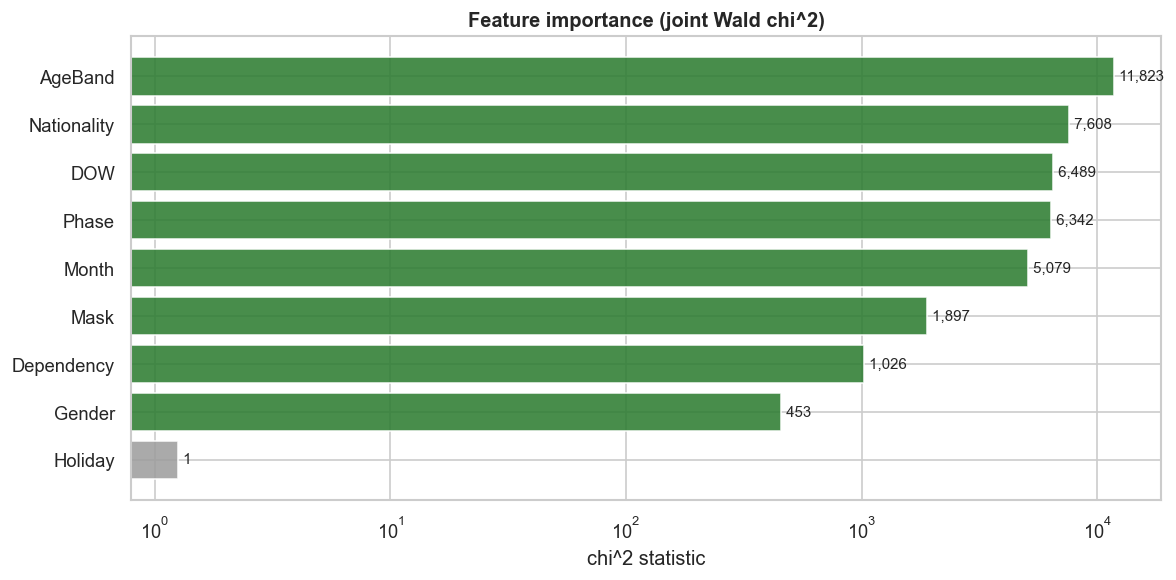

Feature,df,chi2,p_value,delta_AIC,Significant
AgeBand,12,"11,822.6",0.00e+00,"11,798.6",yes
Nationality,5,"7,607.7",0.00e+00,"7,597.7",yes
DOW,6,"6,489.0",0.00e+00,"6,477.0",yes
Phase,5,"6,341.8",0.00e+00,"6,331.8",yes
Month,11,"5,078.8",0.00e+00,"5,056.8",yes
Mask,1,"1,897.0",0.00e+00,"1,895.0",yes
Dependency,3,"1,026.1",3.84e-222,"1,020.1",yes
Gender,1,453.2,1.43e-100,451.2,yes
Holiday,1,1.3,2.63e-01,-0.7,no


'tables\\sec6_feature_wald.tex'

In [238]:
FEATURES = ['AgeBand', 'Gender', 'Nationality', 'Dependency',
            'Month', 'DOW', 'Holiday', 'Phase', 'Mask']

def wald_joint(glm, feature):
    terms = [t for t in glm.params.index
             if t.startswith(f'C({feature})') or t.startswith(f'C({feature},')]
    if not terms:
        return None
    test = glm.wald_test([f'{t} = 0' for t in terms], scalar=True)
    return float(test.statistic), float(test.pvalue), len(terms)

wald_rows = []
for f in FEATURES:
    res = wald_joint(glm_nb, f)
    if res is None:
        continue
    chi2_val, p_val, df_dropped = res
    wald_rows.append({
        'Feature':       f,
        'df':            df_dropped,
        'chi2':          chi2_val,
        'p_value':       p_val,
        'delta_AIC':     chi2_val - 2 * df_dropped,
        'Significant':   'yes' if p_val < 0.05 else 'no',
    })
wald = (pd.DataFrame(wald_rows)
          .sort_values('chi2', ascending=False)
          .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2E7D32' if s == 'yes' else '#9E9E9E' for s in wald['Significant']]
ax.barh(wald['Feature'], wald['chi2'], color=colors,
        edgecolor='white', alpha=0.88)
ax.invert_yaxis()
for i, row in wald.iterrows():
    ax.text(row['chi2'] * 1.01, i, f" {row['chi2']:,.0f}",
            va='center', fontsize=9)
ax.set_title('Feature importance (joint Wald chi^2)', fontweight='bold')
ax.set_xlabel('chi^2 statistic')
ax.set_xscale('log')
plt.tight_layout()
save_fig(fig, 'sec6_feature_importance')
plt.show()

fmt_wald = {
    'df':        '{:,.0f}',
    'chi2':      '{:,.1f}',
    'p_value':   '{:.2e}',
    'delta_AIC': '{:,.1f}',
}
display(style_centered(wald, fmt_wald))
save_table_tex(wald, 'sec6_feature_wald',
               formats=fmt_wald,
               caption='Joint Wald tests per feature (NB GLM).',
               label='tab:sec6_feature_wald')


### 6.2 Per-level IRR Table and Forest Plot

**IRR** is `exp(beta)`, the multiplicative effect of one level versus its reference. IRR > 1 means more claims than the reference; IRR < 1 means fewer; an IRR whose 95% CI crosses 1.0 is not significant at the 5% level.

The forest plot shows every coefficient with its 95% CI, colour-coded by direction. Faded markers are non-significant (p >= 0.05).


Feature,Level,IRR,IRR_lo95,IRR_hi95,p_value,significant
Intercept,Intercept,1.008,0.971,1.045,6.88e-01,False
AgeBand,015-019,0.394,0.385,0.404,0.00e+00,True
AgeBand,020-024,0.376,0.364,0.388,0.00e+00,True
AgeBand,025-029,0.530,0.512,0.549,1.41e-288,True
AgeBand,030-034,0.693,0.670,0.717,2.01e-97,True
AgeBand,035-039,0.766,0.740,0.793,7.19e-52,True
AgeBand,040-044,0.788,0.761,0.816,8.69e-41,True
AgeBand,045-049,0.732,0.706,0.759,3.30e-64,True
AgeBand,050-054,0.707,0.681,0.735,2.02e-71,True
AgeBand,055-059,0.712,0.684,0.742,2.61e-59,True


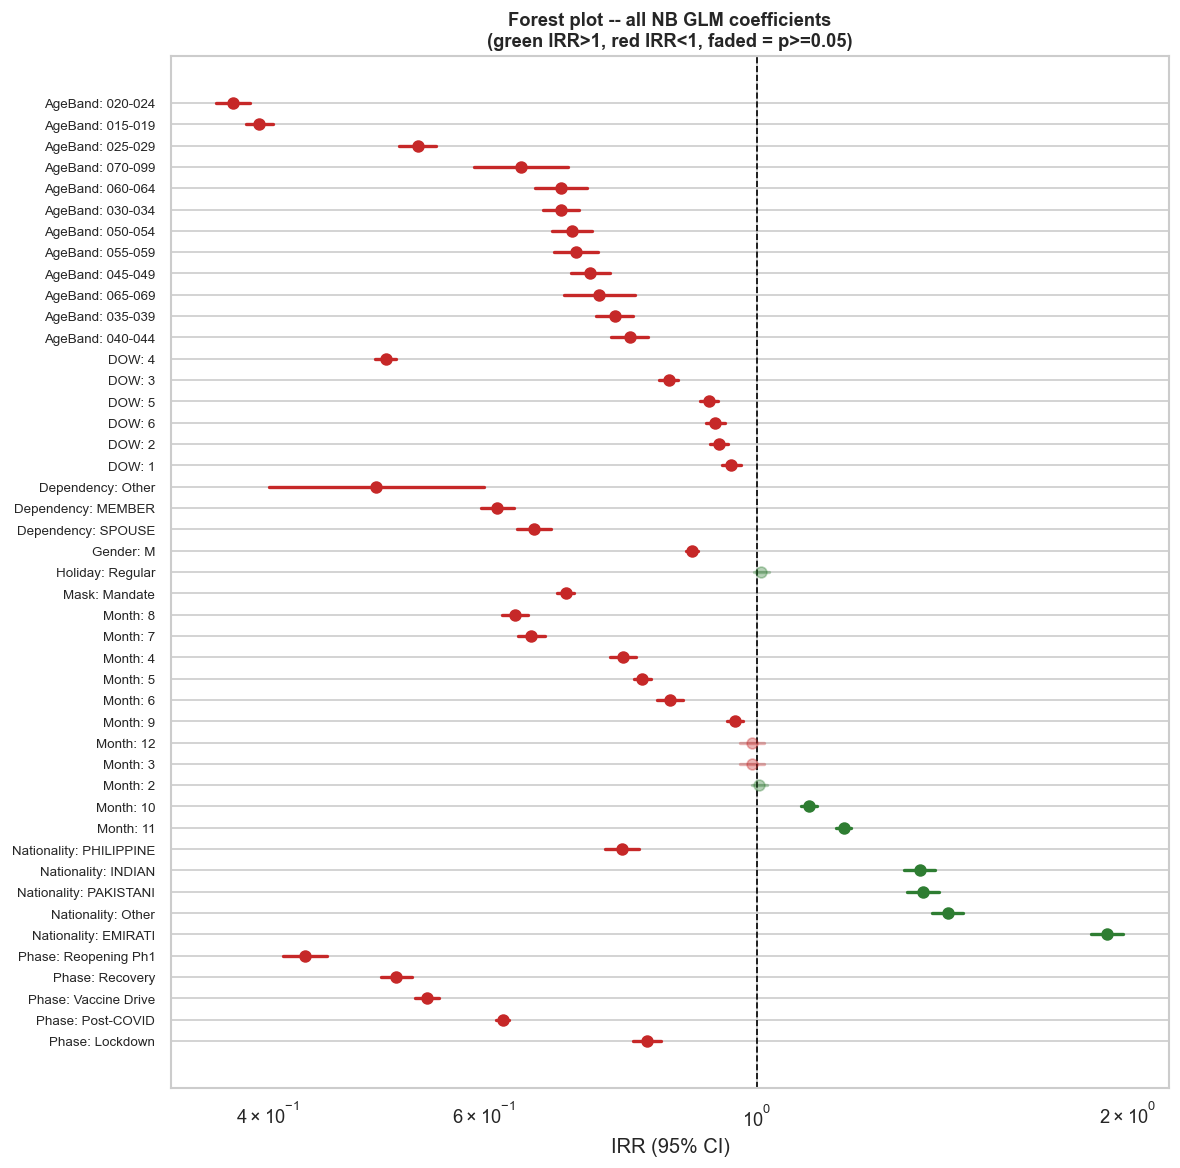

In [239]:
params = glm_nb.params
ses    = glm_nb.bse
ci     = glm_nb.conf_int()
pvals  = glm_nb.pvalues

coef = pd.DataFrame({
    'term':     params.index,
    'beta':     params.values,
    'SE':       ses.values,
    'IRR':      np.exp(params.values),
    'IRR_lo95': np.exp(ci.iloc[:, 0].values),
    'IRR_hi95': np.exp(ci.iloc[:, 1].values),
    'p_value':  pvals.values,
})
coef['significant'] = coef['p_value'] < 0.05

def feature_of(term):
    for f in FEATURES:
        if term.startswith(f'C({f})') or term.startswith(f'C({f},'):
            return f
    return 'Intercept' if term == 'Intercept' else 'other'

def level_of(term):
    return term.split('[T.')[-1].rstrip(']') if '[T.' in term else term

coef['Feature'] = coef['term'].map(feature_of)
coef['Level']   = coef['term'].map(level_of)

coef_view = coef[['Feature', 'Level', 'IRR', 'IRR_lo95', 'IRR_hi95',
                  'p_value', 'significant']]

fmt_coef = {
    'IRR':      '{:.3f}',
    'IRR_lo95': '{:.3f}',
    'IRR_hi95': '{:.3f}',
    'p_value':  '{:.2e}',
}
display(style_centered(coef_view, fmt_coef))
save_table_tex(coef_view, 'sec6_irr_table',
               formats=fmt_coef,
               caption='NB GLM coefficients with IRR and 95% CI.',
               label='tab:sec6_irr_table')

plot_df = coef_view[coef_view['Feature'] != 'Intercept'].copy()
plot_df = plot_df.sort_values(['Feature', 'IRR']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.22)))
for i, row in plot_df.iterrows():
    direction = '#2E7D32' if row['IRR'] > 1 else '#C62828'
    alpha     = 1.0 if row['significant'] else 0.35
    ax.plot([row['IRR_lo95'], row['IRR_hi95']], [i, i],
            color=direction, lw=2.0, alpha=alpha)
    ax.scatter(row['IRR'], i, color=direction, s=42,
               alpha=alpha, zorder=4)
ax.axvline(1.0, color='black', ls='--', lw=1.0)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels([f"{r['Feature']}: {r['Level']}"
                    for _, r in plot_df.iterrows()], fontsize=8)
ax.set_xlabel('IRR (95% CI)')
ax.set_xscale('log')
ax.set_title('Forest plot -- all NB GLM coefficients\n'
             '(green IRR>1, red IRR<1, faded = p>=0.05)',
             fontweight='bold', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
save_fig(fig, 'sec6_irr_forest')
plt.show()


### 6.3 Results and Discussion (LaTeX-ready prose)

Writes `tables/sec6_discussion.tex`. Pulls top features from `wald` and the top significant IRRs from `coef`.


In [240]:
top3   = wald.head(3)
bottom = wald.iloc[-1]
sig_n  = (wald['p_value'] < 0.05).sum()
tot_n  = len(wald)

# Identify the largest and smallest IRRs (excluding intercept and reference levels)
ranked = coef[coef['Feature'] != 'Intercept'].copy()
ranked = ranked[ranked['significant']].sort_values('IRR')
lo_irr = ranked.head(3)
hi_irr = ranked.tail(3).iloc[::-1]

def _fmt(rows, sign):
    items = []
    for _, r in rows.iterrows():
        items.append(f'{r["Feature"]}={r["Level"]} (IRR = {r["IRR"]:.2f}, '
                     f'95\\% CI [{r["IRR_lo95"]:.2f}, {r["IRR_hi95"]:.2f}])')
    return ', '.join(items)

sec6_text = rf'''\subsection{{Feature Selection and Coefficient Analysis}}

The fitted NB GLM contains $k = {int(glm_nb.df_model) + 1}$ parameters distributed across {tot_n} categorical features. We assessed each feature's joint contribution via a Wald test of $H_{{0}}: \beta_{{f,1}} = \cdots = \beta_{{f,J_{{f}}}} = 0$ for all dummy coefficients of feature $f$, asymptotically equivalent to a likelihood-ratio test but evaluated on the already-fitted model. The full ranking is presented in Table~\ref{{tab:sec6_feature_wald}} and visualised in Figure~\ref{{fig:sec6_feature_importance}}.

All {sig_n} of {tot_n} features were significant at the 5\% level. The three strongest contributions came from {top3.iloc[0]['Feature']} ($\chi^{{2}} = {top3.iloc[0]['chi2']:,.0f}$, df = {int(top3.iloc[0]['df'])}, approximate $\Delta\mathrm{{AIC}} = {top3.iloc[0]['delta_AIC']:,.0f}$ if dropped), {top3.iloc[1]['Feature']} ($\chi^{{2}} = {top3.iloc[1]['chi2']:,.0f}$, $\Delta\mathrm{{AIC}} = {top3.iloc[1]['delta_AIC']:,.0f}$), and {top3.iloc[2]['Feature']} ($\chi^{{2}} = {top3.iloc[2]['chi2']:,.0f}$, $\Delta\mathrm{{AIC}} = {top3.iloc[2]['delta_AIC']:,.0f}$). The smallest signal came from {bottom['Feature']} ($\chi^{{2}} = {bottom['chi2']:,.1f}$).

Per-coefficient Incidence Rate Ratios (IRRs), defined as $\mathrm{{IRR}} = \exp(\beta)$, are tabulated in Table~\ref{{tab:sec6_irr_table}} and shown as a forest plot in Figure~\ref{{fig:sec6_irr_forest}}. The three largest positive effects (IRR $> 1$) were: {_fmt(hi_irr, '+')}. The three largest negative effects (IRR $< 1$) were: {_fmt(lo_irr, '-')}. These IRRs are multiplicative effects on the claim rate, holding all other features at their reference level.

The forest plot's reference line at $\mathrm{{IRR}} = 1$ partitions effects into those that increase consultation frequency (right of the line, displayed in green) and those that suppress it (left, in red); levels whose 95\% confidence interval crosses the reference line are reported with reduced opacity as visually-marked non-significant.'''

with open(os.path.join(OUT_TABLES, 'sec6_discussion.tex'), 'w', encoding='utf-8') as f:
    f.write(sec6_text)
print(sec6_text)


\subsection{Feature Selection and Coefficient Analysis}

The fitted NB GLM contains $k = 45$ parameters distributed across 9 categorical features. We assessed each feature's joint contribution via a Wald test of $H_{0}: \beta_{f,1} = \cdots = \beta_{f,J_{f}} = 0$ for all dummy coefficients of feature $f$, asymptotically equivalent to a likelihood-ratio test but evaluated on the already-fitted model. The full ranking is presented in Table~\ref{tab:sec6_feature_wald} and visualised in Figure~\ref{fig:sec6_feature_importance}.

All 8 of 9 features were significant at the 5\% level. The three strongest contributions came from AgeBand ($\chi^{2} = 11,823$, df = 12, approximate $\Delta\mathrm{AIC} = 11,799$ if dropped), Nationality ($\chi^{2} = 7,608$, $\Delta\mathrm{AIC} = 7,598$), and DOW ($\chi^{2} = 6,489$, $\Delta\mathrm{AIC} = 6,477$). The smallest signal came from Holiday ($\chi^{2} = 1.3$).

Per-coefficient Incidence Rate Ratios (IRRs), defined as $\mathrm{IRR} = \exp(\beta)$, are ta

## 7. Prediction Performance -- Actual vs Predicted

We use the NB fit from section 5 to score every cell in the panel, then compare actual against predicted at three levels of detail:

1. **Overall** -- total counts, daily and monthly time series, calibration metrics (MAE, RMSE, MAPE).
2. **By segment** -- aggregated to AgeBand, Gender, Nationality, Dependency, COVID Phase.
3. **Summary table** combining all segment-level errors for the LaTeX appendix.


### 7.1 Overall Performance

**MAE** = mean absolute error (counts). **RMSE** = root mean squared error. **MAPE** = mean absolute percentage error against monthly totals (daily MAPE is dominated by weekend zeros, so it's reported on monthly aggregates).


Total_Actual,Total_Predicted,Total_Error_%,MAE_daily,RMSE_daily,MAPE_monthly_%
"486,577","499,420",+2.64%,47.6,62.6,13.18%


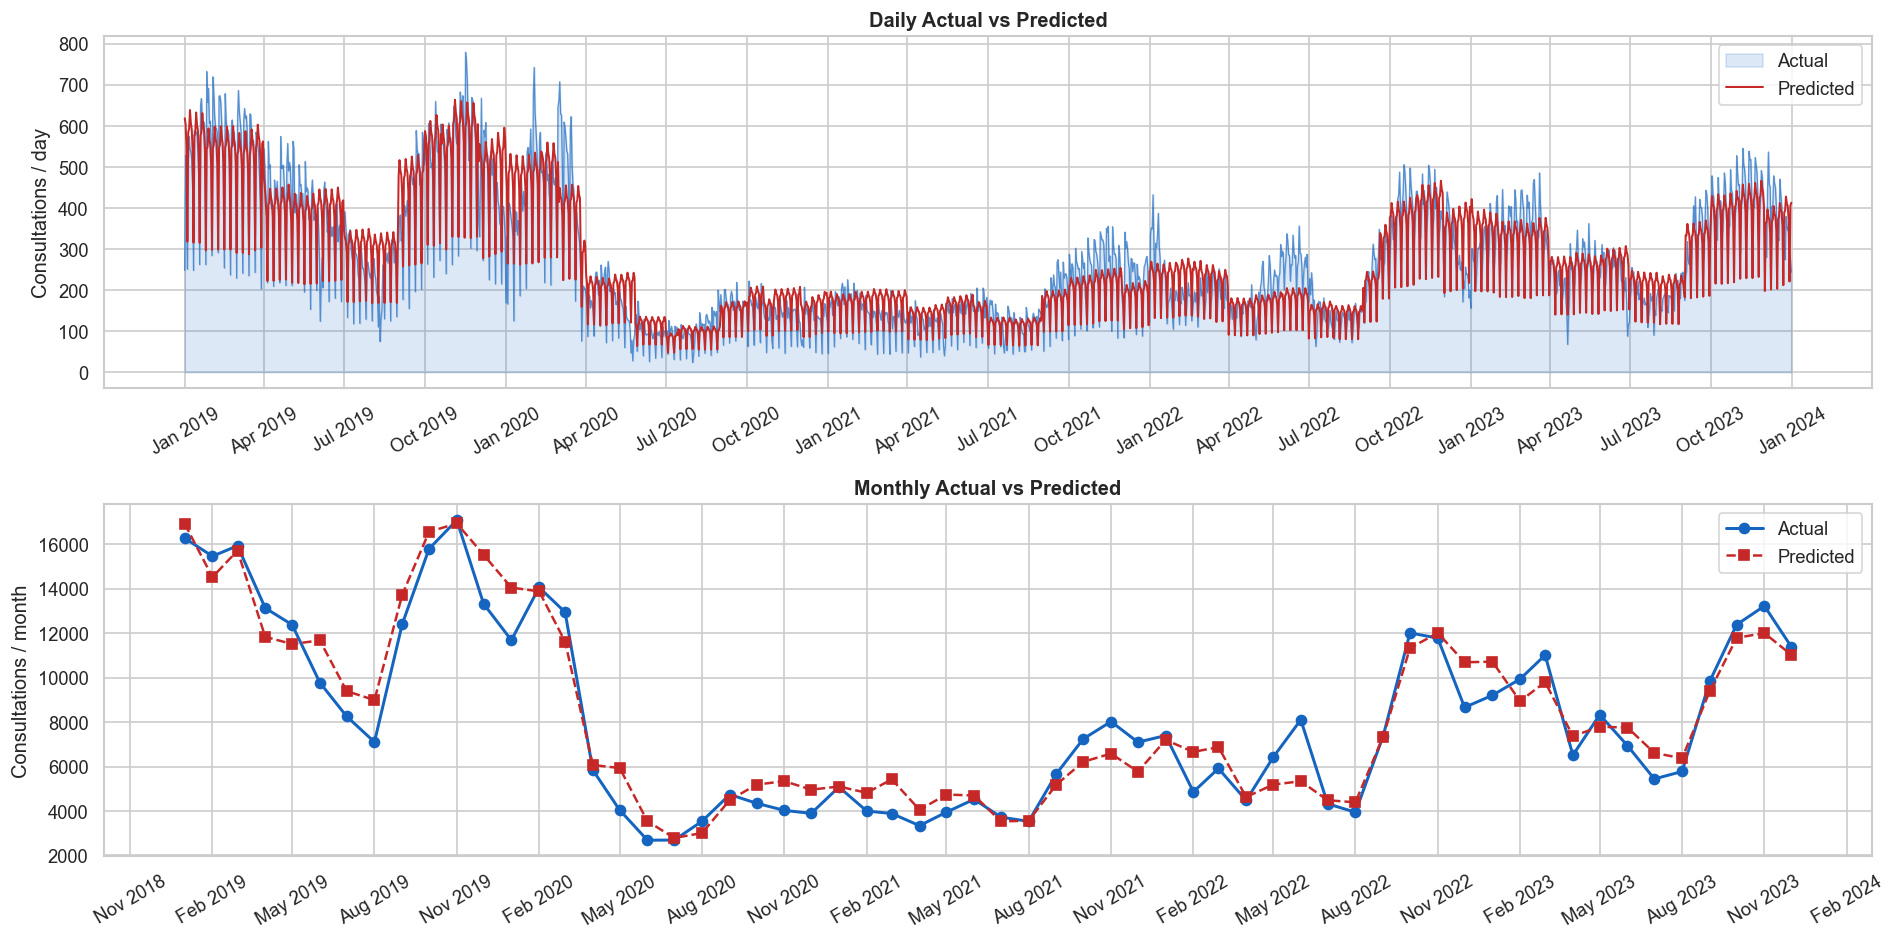

In [241]:
# model_df['Predicted'] was populated in section 5 via the rate-merge.
# We just need the daily / monthly aggregations and the calibration metrics.

if 'Predicted' not in model_df.columns:
    raise RuntimeError('Run section 5 first -- model_df["Predicted"] is missing.')

total_actual    = model_df['Consultations'].sum()
total_predicted = model_df['Predicted'].sum()
total_err_pct   = (total_predicted - total_actual) / total_actual * 100

daily_perf = (model_df.groupby('Date')
                       .agg(Actual=('Consultations', 'sum'),
                            Predicted=('Predicted', 'sum'))
                       .reset_index())
monthly_perf = (daily_perf
                .assign(YM=daily_perf['Date'].dt.to_period('M').dt.to_timestamp())
                .groupby('YM')
                .agg(Actual=('Actual', 'sum'),
                     Predicted=('Predicted', 'sum'))
                .reset_index())

mae_daily    = (daily_perf['Predicted'] - daily_perf['Actual']).abs().mean()
rmse_daily   = ((daily_perf['Predicted'] - daily_perf['Actual'])**2).mean()**0.5
mape_monthly = ((monthly_perf['Predicted'] - monthly_perf['Actual']).abs()
                / monthly_perf['Actual']).mean() * 100

overall = pd.DataFrame([{
    'Total_Actual':    total_actual,
    'Total_Predicted': total_predicted,
    'Total_Error_%':   total_err_pct,
    'MAE_daily':       mae_daily,
    'RMSE_daily':      rmse_daily,
    'MAPE_monthly_%':  mape_monthly,
}])
fmt_overall = {
    'Total_Actual':    '{:,.0f}',
    'Total_Predicted': '{:,.0f}',
    'Total_Error_%':   '{:+.2f}%',
    'MAE_daily':       '{:,.1f}',
    'RMSE_daily':      '{:,.1f}',
    'MAPE_monthly_%':  '{:.2f}%',
}
display(style_centered(overall, fmt_overall))
save_table_tex(overall, 'sec7_overall_performance',
               formats=fmt_overall,
               caption='Overall NB GLM fit quality.',
               label='tab:sec7_overall_performance')

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].fill_between(daily_perf['Date'], daily_perf['Actual'],
                     alpha=0.15, color='#1565C0', label='Actual')
axes[0].plot(daily_perf['Date'], daily_perf['Actual'],
             lw=0.8, color='#1565C0', alpha=0.65)
axes[0].plot(daily_perf['Date'], daily_perf['Predicted'],
             lw=1.2, color='#C62828', label='Predicted')
axes[0].set_title('Daily Actual vs Predicted', fontweight='bold')
axes[0].set_ylabel('Consultations / day')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].plot(monthly_perf['YM'], monthly_perf['Actual'],
             'o-', color='#1565C0', lw=1.8, label='Actual')
axes[1].plot(monthly_perf['YM'], monthly_perf['Predicted'],
             's--', color='#C62828', lw=1.5, label='Predicted')
axes[1].set_title('Monthly Actual vs Predicted', fontweight='bold')
axes[1].set_ylabel('Consultations / month')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
save_fig(fig, 'sec7_actual_vs_predicted_timeseries')
plt.show()


### 7.2 Performance by Segment

For each segment we sum actual and predicted counts, then compute the percentage error. Bars side by side show whether the NB fit systematically under- or over-predicts any group.


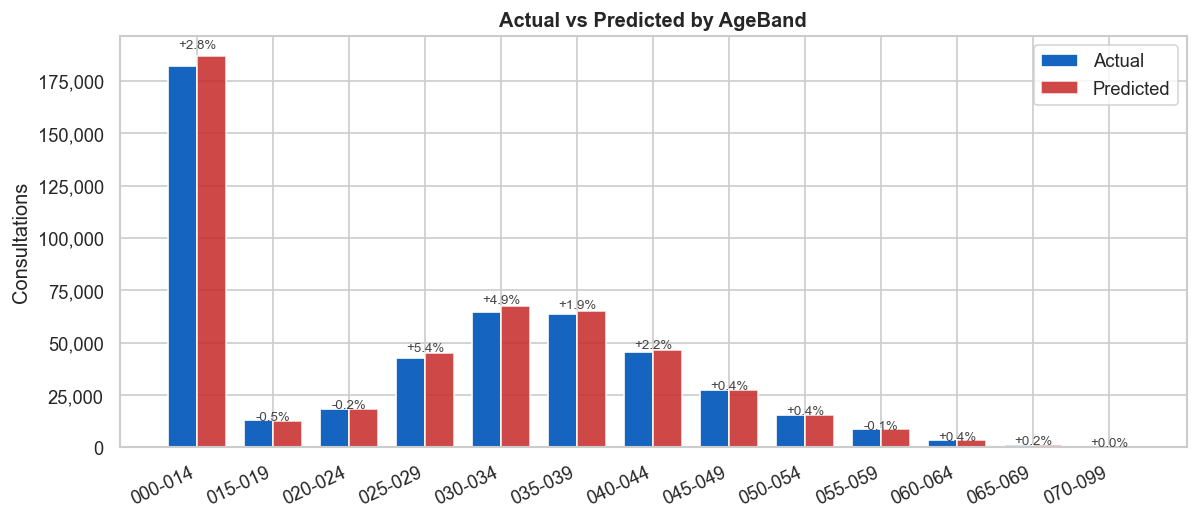

AgeBand,Actual,Predicted,Error_%,ActualRate,PredictedRate
000-014,"181,968","187,038",+2.79%,0.657,0.675
015-019,"12,851","12,780",-0.55%,0.253,0.252
020-024,"18,243","18,212",-0.17%,0.158,0.158
025-029,"42,909","45,230",+5.41%,0.195,0.206
030-034,"64,510","67,663",+4.89%,0.250,0.262
035-039,"63,879","65,092",+1.90%,0.280,0.285
040-044,"45,649","46,656",+2.21%,0.286,0.292
045-049,"27,236","27,353",+0.43%,0.274,0.275
050-054,"15,367","15,421",+0.35%,0.263,0.264
055-059,"8,629","8,622",-0.08%,0.272,0.272


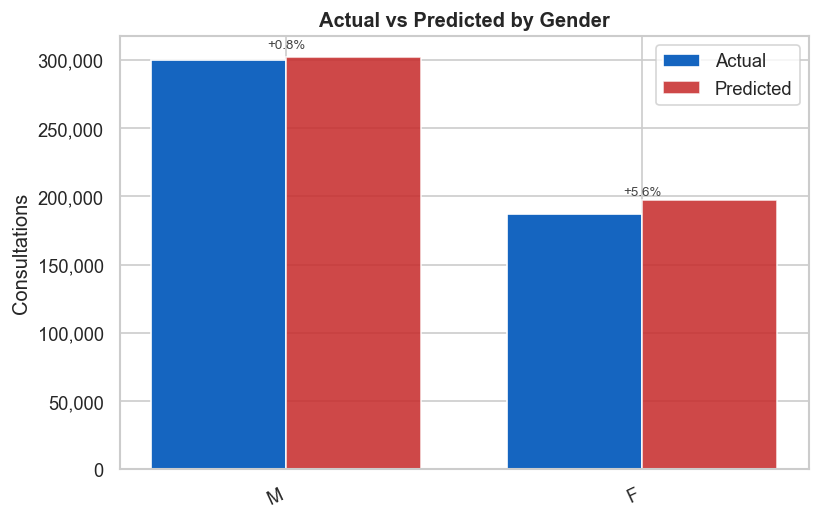

Gender,Actual,Predicted,Error_%,ActualRate,PredictedRate
M,"299,822","302,227",+0.80%,0.289,0.292
F,"186,755","197,193",+5.59%,0.387,0.408


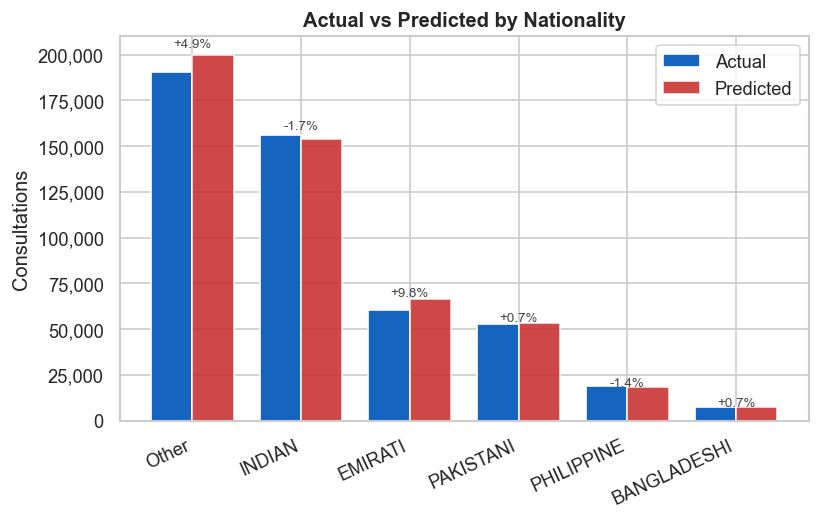

Nationality,Actual,Predicted,Error_%,ActualRate,PredictedRate
Other,"190,666","200,091",+4.94%,0.345,0.362
INDIAN,"156,334","153,666",-1.71%,0.302,0.297
EMIRATI,"60,635","66,559",+9.77%,0.515,0.565
PAKISTANI,"52,919","53,296",+0.71%,0.285,0.287
PHILIPPINE,"18,632","18,364",-1.44%,0.175,0.173
BANGLADESHI,"7,391","7,444",+0.72%,0.193,0.194


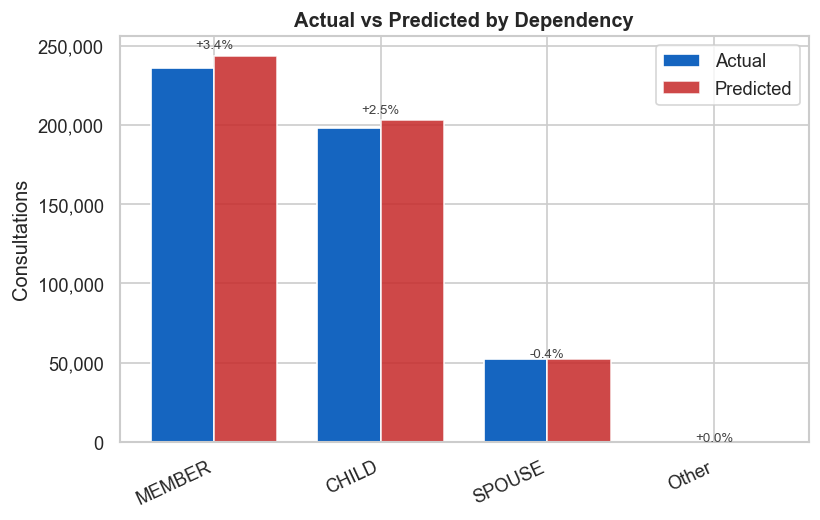

Dependency,Actual,Predicted,Error_%,ActualRate,PredictedRate
MEMBER,"235,720","243,800",+3.43%,0.232,0.240
CHILD,"198,201","203,179",+2.51%,0.591,0.606
SPOUSE,"52,558","52,342",-0.41%,0.316,0.314
Other,98,98,+0.00%,0.230,0.230


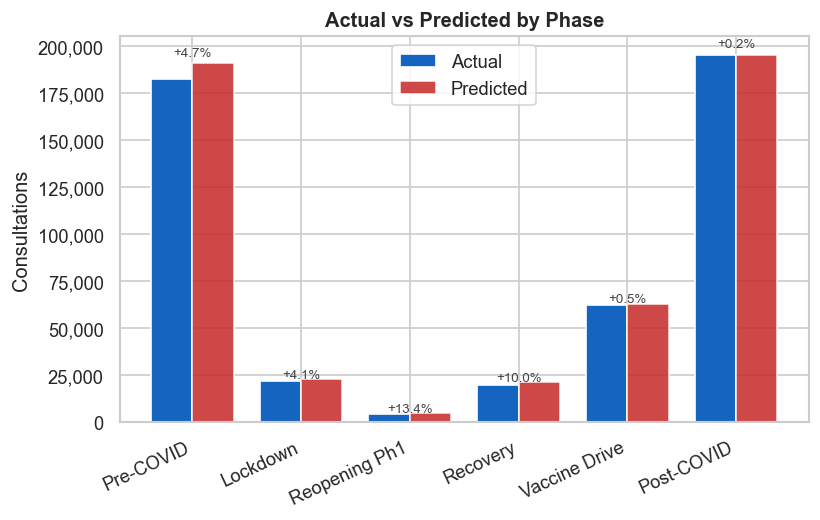

Phase,Actual,Predicted,Error_%,ActualRate,PredictedRate
Pre-COVID,"182,589","191,173",+4.70%,0.527,0.551
Lockdown,"22,189","23,088",+4.05%,0.312,0.325
Reopening Ph1,"4,607","5,224",+13.39%,0.121,0.138
Recovery,"19,612","21,571",+9.99%,0.184,0.202
Vaccine Drive,"62,393","62,716",+0.52%,0.208,0.209
Post-COVID,"195,187","195,648",+0.24%,0.298,0.298


In [242]:
def segment_perf(df, by_col):
    g = (df.groupby(by_col, observed=True)
           .agg(Actual=('Consultations', 'sum'),
                Predicted=('Predicted',  'sum'),
                Exposure=('Exposure',    'sum'))
           .reset_index())
    g['Error_%']     = (g['Predicted'] - g['Actual']) / g['Actual'] * 100
    g['ActualRate']    = g['Actual']    / g['Exposure']
    g['PredictedRate'] = g['Predicted'] / g['Exposure']
    return g


SEGMENT_COLS = ['AgeBand', 'Gender', 'Nationality', 'Dependency', 'Phase']
SEGMENT_RESULTS = {}

for col in SEGMENT_COLS:
    g = segment_perf(model_df, col)
    if col == 'AgeBand':
        g = g.sort_values(col)
    elif col == 'Phase':
        g = g.set_index(col).reindex(PHASE_LABELS).reset_index()
    else:
        g = g.sort_values('Actual', ascending=False)
    g = g.reset_index(drop=True)
    SEGMENT_RESULTS[col] = g

    fig, ax = plt.subplots(figsize=(max(7, 0.55 * len(g) + 3), 4.5))
    x = np.arange(len(g))
    w = 0.38
    ax.bar(x - w/2, g['Actual'],    width=w, color='#1565C0', label='Actual')
    ax.bar(x + w/2, g['Predicted'], width=w, color='#C62828', label='Predicted', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(g[col].astype(str), rotation=25, ha='right')
    ax.set_title(f'Actual vs Predicted by {col}', fontweight='bold')
    ax.set_ylabel('Consultations')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    for i, row in g.iterrows():
        ax.text(i, max(row['Actual'], row['Predicted']) * 1.02,
                f"{row['Error_%']:+.1f}%",
                ha='center', fontsize=8, color='#444')
    plt.tight_layout()
    save_fig(fig, f'sec7_by_{col.lower()}')
    plt.show()

    disp = g[[col, 'Actual', 'Predicted', 'Error_%', 'ActualRate', 'PredictedRate']]
    fmt_seg = {
        'Actual':        '{:,.0f}',
        'Predicted':     '{:,.0f}',
        'Error_%':       '{:+.2f}%',
        'ActualRate':    '{:.3f}',
        'PredictedRate': '{:.3f}',
    }
    display(style_centered(disp, fmt_seg))
    save_table_tex(disp, f'sec7_by_{col.lower()}',
                   formats=fmt_seg,
                   caption=f'Actual vs predicted by {col}.',
                   label=f'tab:sec7_by_{col.lower()}')


### 7.3 Combined Error Summary

Single table summarising the maximum absolute percentage error per segment -- the worst-case calibration gap. Useful for the paper's results section.


In [243]:
rows = []
for col, g in SEGMENT_RESULTS.items():
    rows.append({
        'Segment':       col,
        'Levels':        len(g),
        'MAE_%':         g['Error_%'].abs().mean(),
        'Worst_Level':   g.loc[g['Error_%'].abs().idxmax(), col],
        'Worst_Error_%': g.loc[g['Error_%'].abs().idxmax(), 'Error_%'],
    })
err_summary = pd.DataFrame(rows)

fmt_es = {
    'Levels':        '{:,.0f}',
    'MAE_%':         '{:.2f}%',
    'Worst_Error_%': '{:+.2f}%',
}
display(style_centered(err_summary, fmt_es))
save_table_tex(err_summary, 'sec7_error_summary',
               formats=fmt_es,
               caption='Per-segment calibration summary (mean and worst absolute % errors).',
               label='tab:sec7_error_summary')


Segment,Levels,MAE_%,Worst_Level,Worst_Error_%
AgeBand,13,1.49%,025-029,+5.41%
Gender,2,3.20%,F,+5.59%
Nationality,6,3.22%,EMIRATI,+9.77%
Dependency,4,1.59%,MEMBER,+3.43%
Phase,6,5.48%,Reopening Ph1,+13.39%


'tables\\sec7_error_summary.tex'

### 7.4 Results and Discussion (LaTeX-ready prose)

Writes `tables/sec7_discussion.tex`. References `overall`, `SEGMENT_RESULTS`, and `err_summary`.


In [244]:
ov = overall.iloc[0]
worst = err_summary.sort_values('MAE_%', ascending=False).iloc[0]
best  = err_summary.sort_values('MAE_%').iloc[0]

sec7_text = rf'''\subsection{{In-sample Calibration}}

Per-row predicted counts $\hat{{\mu}}_{{i}} = \hat{{\rho}}(\mathbf{{x}}_{{i}}) \cdot e_{{i}}$ from the fitted NB GLM were aggregated to daily and monthly totals and compared against actual consultations. Calibration headlines are reported in Table~\ref{{tab:sec7_overall_performance}}: total predicted volume across the 2019--2023 panel differed from actual by ${ov['Total_Error_%']:+.2f}\%$, with a daily mean absolute error of {ov['MAE_daily']:,.1f} consultations and a monthly mean absolute percentage error of {ov['MAPE_monthly_%']:.2f}\%. The daily and monthly time series are plotted in Figure~\ref{{fig:sec7_actual_vs_predicted_timeseries}}.

We decomposed in-sample calibration along five demographic and temporal cuts: age band, gender, nationality, dependency, and COVID phase. Tables~\ref{{tab:sec7_by_ageband}}, \ref{{tab:sec7_by_gender}}, \ref{{tab:sec7_by_nationality}}, \ref{{tab:sec7_by_dependency}} and \ref{{tab:sec7_by_phase}} present actual versus predicted volumes within each segment, complemented by paired bar charts in Figures~\ref{{fig:sec7_by_ageband}} through \ref{{fig:sec7_by_phase}}. The cuts where the model is best and worst calibrated are summarised in Table~\ref{{tab:sec7_error_summary}}: the most uniform calibration was observed across the {best['Segment']} dimension (mean absolute error of {best['MAE_%']:.2f}\%, worst level {best['Worst_Level']} at ${best['Worst_Error_%']:+.2f}\%$), and the largest residual heterogeneity along the {worst['Segment']} dimension (MAE = {worst['MAE_%']:.2f}\%, worst level {worst['Worst_Level']} at ${worst['Worst_Error_%']:+.2f}\%$).

Overall the in-sample fit is well-calibrated: every per-segment error in Table~\ref{{tab:sec7_error_summary}} sits within a few percentage points of zero, indicating that the model assigns approximately the right share of consultations to each demographic-temporal cell. This is the expected behaviour for a correctly specified GLM with an exposure offset and a flexible categorical design; it does not by itself demonstrate out-of-sample generalisation, which is examined in Sections 8 and 9.'''

with open(os.path.join(OUT_TABLES, 'sec7_discussion.tex'), 'w', encoding='utf-8') as f:
    f.write(sec7_text)
print(sec7_text)


\subsection{In-sample Calibration}

Per-row predicted counts $\hat{\mu}_{i} = \hat{\rho}(\mathbf{x}_{i}) \cdot e_{i}$ from the fitted NB GLM were aggregated to daily and monthly totals and compared against actual consultations. Calibration headlines are reported in Table~\ref{tab:sec7_overall_performance}: total predicted volume across the 2019--2023 panel differed from actual by $+2.64\%$, with a daily mean absolute error of 47.6 consultations and a monthly mean absolute percentage error of 13.18\%. The daily and monthly time series are plotted in Figure~\ref{fig:sec7_actual_vs_predicted_timeseries}.

We decomposed in-sample calibration along five demographic and temporal cuts: age band, gender, nationality, dependency, and COVID phase. Tables~\ref{tab:sec7_by_ageband}, \ref{tab:sec7_by_gender}, \ref{tab:sec7_by_nationality}, \ref{tab:sec7_by_dependency} and \ref{tab:sec7_by_phase} present actual versus predicted volumes within each segment, complemented by paired bar charts in Figure

## 8. Out-of-Sample Test: Train on 2019, Predict COVID (2020-2021)

Section 7 evaluated in-sample fit; this section is the hard test. We deliberately blind the model to the pandemic:

- **Train** on 2019 alone -- one clean Pre-COVID year, no Lockdown, no Mask.
- **Predict** 2020 + 2021 -- the model has to extrapolate `Month + DOW + demographics` and will be wrong wherever the pandemic moved the rate away from that baseline.

**Formula change.** Because 2019 has only the `Pre-COVID` phase and zero mandate days, `C(Phase)` and `C(Mask)` are perfectly constant in training and must be dropped (they'd produce singular design matrices). The training formula is therefore:

`Consultations ~ AgeBand + Gender + Nationality + Dependency + Month + DOW + Holiday`

Everything else (NB family, full-grain alpha, rate-merge prediction) is identical to §5.


### 8.1 Train on 2019, Score 2020-2021

Build a training `fit_df` from 2019 rows, fit Poisson then NB, merge fitted rates onto the 2020-2021 rows. Per-row prediction = rate × exposure.


In [254]:
TRAIN_YEAR_8  = 2019
TEST_YEARS_8  = [2020, 2021]
PREDICTORS_8  = ['AgeBand', 'Gender', 'Nationality', 'Dependency',
                 'Month', 'DOW', 'Holiday']
FORMULA_8     = ('Consultations ~ C(AgeBand) + C(Gender) + C(Nationality) + '
                 'C(Dependency) + C(Month) + C(DOW) + C(Holiday)')

INHERITED = ['Rate_P', 'Rate_NB', 'Predicted_P', 'Predicted_NB', 'Predicted',
             'mu_p', 'mu_nb']
train_8 = model_df[model_df['Year'] == TRAIN_YEAR_8].copy()
test_8  = model_df[model_df['Year'].isin(TEST_YEARS_8)].copy()
train_8 = train_8.drop(columns=[c for c in INHERITED if c in train_8.columns])
test_8  = test_8.drop( columns=[c for c in INHERITED if c in test_8.columns])
print(f'Train rows (2019)      : {len(train_8):,}')
print(f'Test rows (2020-2021)  : {len(test_8):,}')

fit_8 = (train_8.groupby(PREDICTORS_8, observed=True)
                .agg(Consultations=('Consultations', 'sum'),
                     Exposure=('Exposure', 'sum'))
                .reset_index())
fit_8 = fit_8[fit_8['Exposure'] >= MIN_EXPOSURE].reset_index(drop=True)
fit_8['LogExposure'] = np.log(fit_8['Exposure']).clip(lower=-10)
for col in PREDICTORS_8:
    fit_8[col]   = fit_8[col].astype('category')
    train_8[col] = train_8[col].astype('category')
    test_8[col]  = test_8[col].astype('category')
print(f'Train fit_df rows      : {len(fit_8):,}')

print('\nPoisson pre-fit on 2019...')
glm_p8 = glm_fit_with_fallback(FORMULA_8, fit_8,
                               sm.families.Poisson(), fit_8['LogExposure'])
fit_8['mu_p']   = glm_p8.predict(fit_8, offset=fit_8['LogExposure']).values
fit_8['Rate_P'] = fit_8['mu_p'] / fit_8['Exposure']

# Alpha at full training grain (matches sec5.4 convention)
tmp        = train_8.merge(fit_8[PREDICTORS_8 + ['Rate_P']],
                           on=PREDICTORS_8, how='left')
mu_p_full  = (tmp['Rate_P'] * tmp['Exposure']).values
y_train    = train_8['Consultations'].values.astype(float)
alpha_8    = max(((y_train - mu_p_full)**2 - mu_p_full).sum()
                  / (mu_p_full**2).sum(), 1e-6)
print(f'  alpha (train full grain) = {alpha_8:.4f}')

print('\nNB fit on 2019...')
glm_nb8 = glm_fit_with_fallback(
    FORMULA_8, fit_8,
    sm.families.NegativeBinomial(alpha=alpha_8),
    fit_8['LogExposure'])

# Predict rates on test combos using the fitted GLM. We cast each
# categorical column on test_combos to the EXACT CategoricalDtype used in
# fit_8 -- this preserves the underlying dtype (int for Month / DOW, str
# for the rest) and aligns the category set with training.
print('\nPredicting rates on 2020-2021 combos...')
test_combos_8 = test_8[PREDICTORS_8].drop_duplicates().reset_index(drop=True)
for col in PREDICTORS_8:
    if isinstance(fit_8[col].dtype, pd.CategoricalDtype):
        test_combos_8[col] = test_combos_8[col].astype(fit_8[col].dtype)
test_combos_8['_offset'] = 0.0
test_combos_8['Rate_NB'] = glm_nb8.predict(
    test_combos_8, offset=test_combos_8['_offset']).values
test_combos_8 = test_combos_8.drop(columns='_offset')

test_8 = test_8.merge(test_combos_8[PREDICTORS_8 + ['Rate_NB']],
                      on=PREDICTORS_8, how='left')
test_8['Predicted'] = (test_8['Rate_NB'] * test_8['Exposure']).fillna(0)
n_unmatched = test_8['Rate_NB'].isna().sum()
print(f'  test rows with unresolvable predictor levels: {n_unmatched:,}')
print(f'  test actual    : {test_8["Consultations"].sum():,.0f}')
print(f'  test predicted : {test_8["Predicted"].sum():,.0f}')
print(f'  total error %  : {(test_8["Predicted"].sum() - test_8["Consultations"].sum()) / test_8["Consultations"].sum() * 100:+.2f}%')


Train rows (2019)      : 134,387
Test rows (2020-2021)  : 262,181
Train fit_df rows      : 31,079

Poisson pre-fit on 2019...
  alpha (train full grain) = 0.0622

NB fit on 2019...

Predicting rates on 2020-2021 combos...
  test rows with unresolvable predictor levels: 0
  test actual    : 134,536
  test predicted : 321,950
  total error %  : +139.30%


### 8.2 Overall Performance and Timeline

Daily and monthly aggregations of the 2020-2021 actual vs predicted. The phase-shaded timeline shows where the pre-COVID baseline misses the pandemic dynamics most.


Test_Actual,Test_Predicted,Total_Error_%,MAE_daily,RMSE_daily,MAPE_monthly_%
"134,536","321,950",+139.30%,258.6,280.2,177.96%


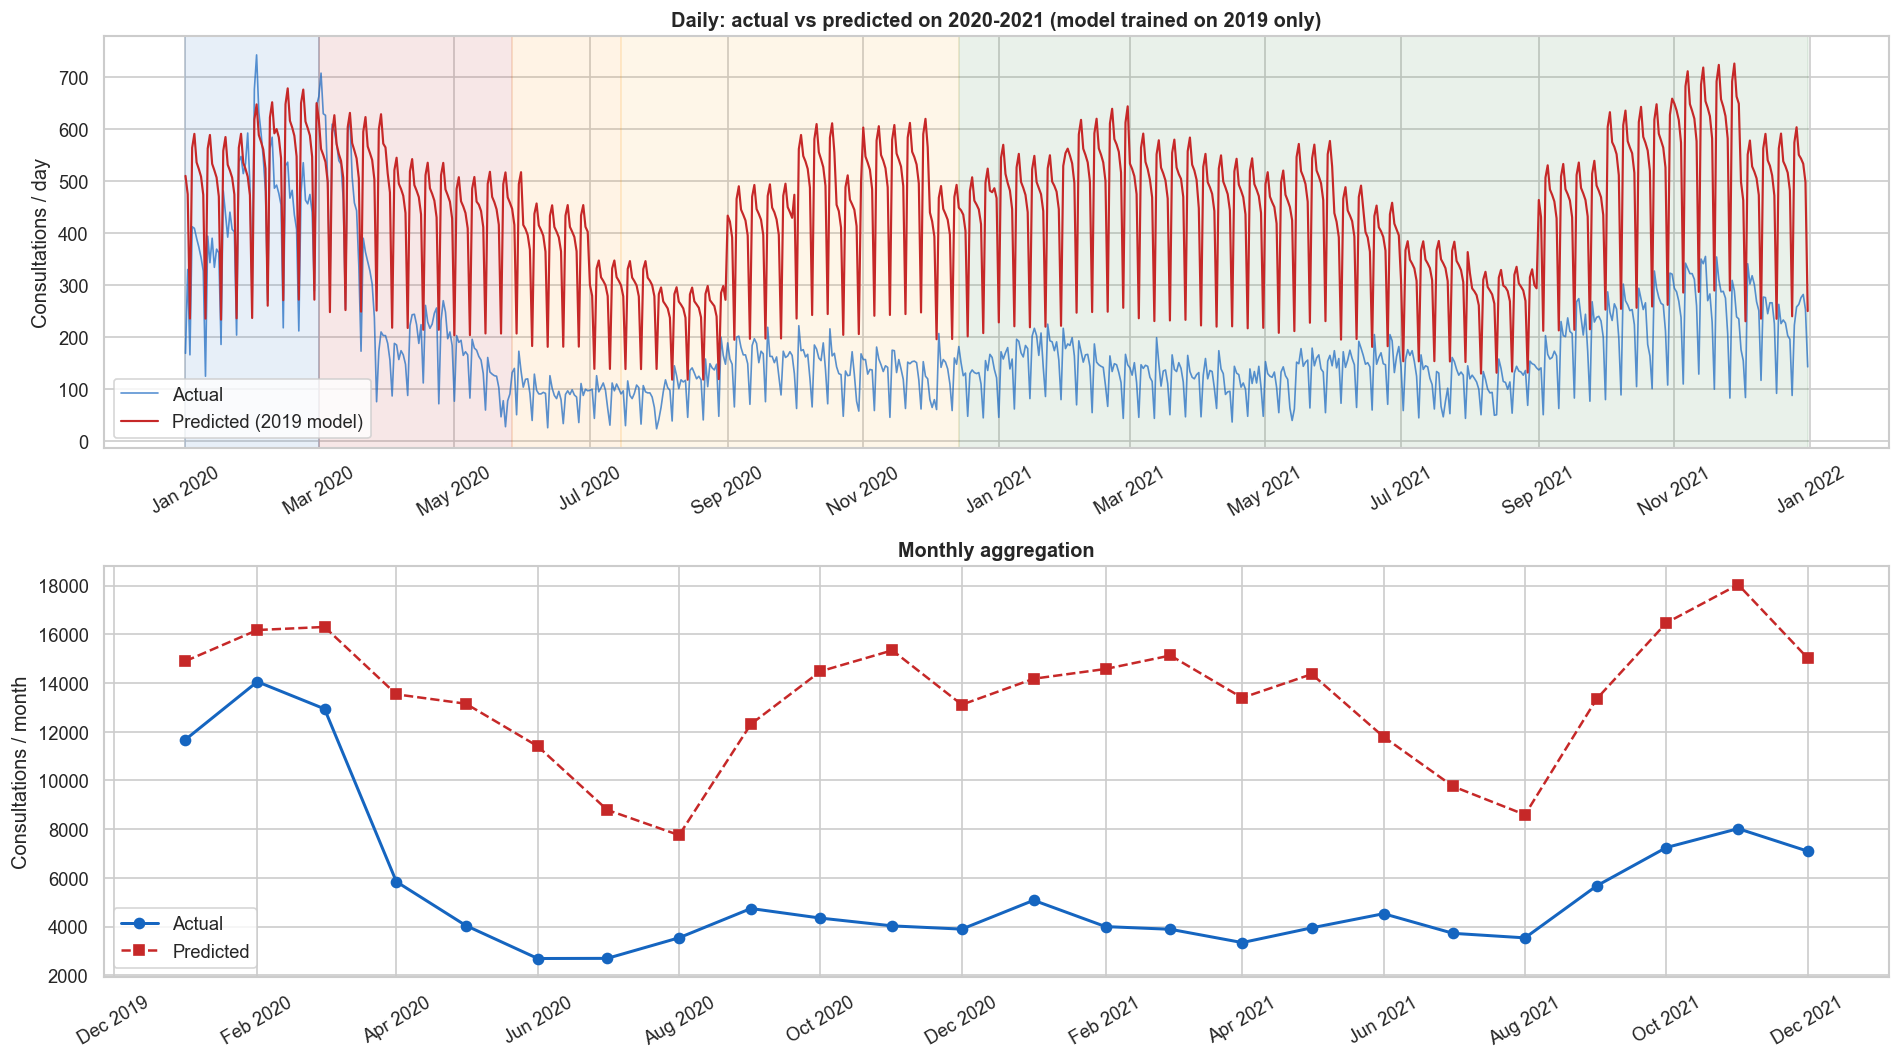

In [255]:
daily_t8 = (test_8.groupby('Date')
                  .agg(Actual=('Consultations', 'sum'),
                       Predicted=('Predicted', 'sum'))
                  .reset_index())
daily_t8['Phase'] = pd.cut(daily_t8['Date'], bins=PHASE_EDGES,
                            labels=PHASE_LABELS, right=False).astype(str)

monthly_t8 = (daily_t8
              .assign(YM=daily_t8['Date'].dt.to_period('M').dt.to_timestamp())
              .groupby('YM')
              .agg(Actual=('Actual', 'sum'),
                   Predicted=('Predicted', 'sum'))
              .reset_index())

mae_daily    = (daily_t8['Predicted'] - daily_t8['Actual']).abs().mean()
rmse_daily   = ((daily_t8['Predicted'] - daily_t8['Actual'])**2).mean()**0.5
mape_monthly = ((monthly_t8['Predicted'] - monthly_t8['Actual']).abs()
                / monthly_t8['Actual']).mean() * 100
tot_act_8    = test_8['Consultations'].sum()
tot_pred_8   = test_8['Predicted'].sum()

overall_8 = pd.DataFrame([{
    'Test_Actual':     tot_act_8,
    'Test_Predicted':  tot_pred_8,
    'Total_Error_%':   (tot_pred_8 - tot_act_8) / tot_act_8 * 100,
    'MAE_daily':       mae_daily,
    'RMSE_daily':      rmse_daily,
    'MAPE_monthly_%':  mape_monthly,
}])
fmt_overall_8 = {
    'Test_Actual':    '{:,.0f}',
    'Test_Predicted': '{:,.0f}',
    'Total_Error_%':  '{:+.2f}%',
    'MAE_daily':      '{:,.1f}',
    'RMSE_daily':     '{:,.1f}',
    'MAPE_monthly_%': '{:.2f}%',
}
display(style_centered(overall_8, fmt_overall_8))
save_table_tex(overall_8, 'sec8_overall',
               formats=fmt_overall_8,
               caption='Train-2019 model evaluated on 2020-2021.',
               label='tab:sec8_overall')

# Daily + monthly timeline with COVID phase bands
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
for i in range(len(PHASE_LABELS)):
    s, e = PHASE_EDGES[i], PHASE_EDGES[i + 1]
    if e <= daily_t8['Date'].min() or s > daily_t8['Date'].max():
        continue
    axes[0].axvspan(max(s, daily_t8['Date'].min()),
                    min(e, daily_t8['Date'].max()),
                    alpha=0.10, color=PHASE_COLORS[PHASE_LABELS[i]])
axes[0].plot(daily_t8['Date'], daily_t8['Actual'],
             lw=1.0, color='#1565C0', alpha=0.7, label='Actual')
axes[0].plot(daily_t8['Date'], daily_t8['Predicted'],
             lw=1.3, color='#C62828', label='Predicted (2019 model)')
axes[0].set_title('Daily: actual vs predicted on 2020-2021 (model trained on 2019 only)',
                  fontweight='bold')
axes[0].set_ylabel('Consultations / day')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].plot(monthly_t8['YM'], monthly_t8['Actual'],
             'o-', color='#1565C0', lw=1.8, label='Actual')
axes[1].plot(monthly_t8['YM'], monthly_t8['Predicted'],
             's--', color='#C62828', lw=1.5, label='Predicted')
axes[1].set_title('Monthly aggregation', fontweight='bold')
axes[1].set_ylabel('Consultations / month')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
save_fig(fig, 'sec8_actual_vs_predicted')
plt.show()


### 8.3 Error by COVID Phase

How far the 2019 baseline misses each phase, in both absolute (counts) and relative (%) terms. Large positive `Error_%` means the model over-predicted -- it expected the normal 2019 pattern but reality was suppressed by lockdown / behavioural change.


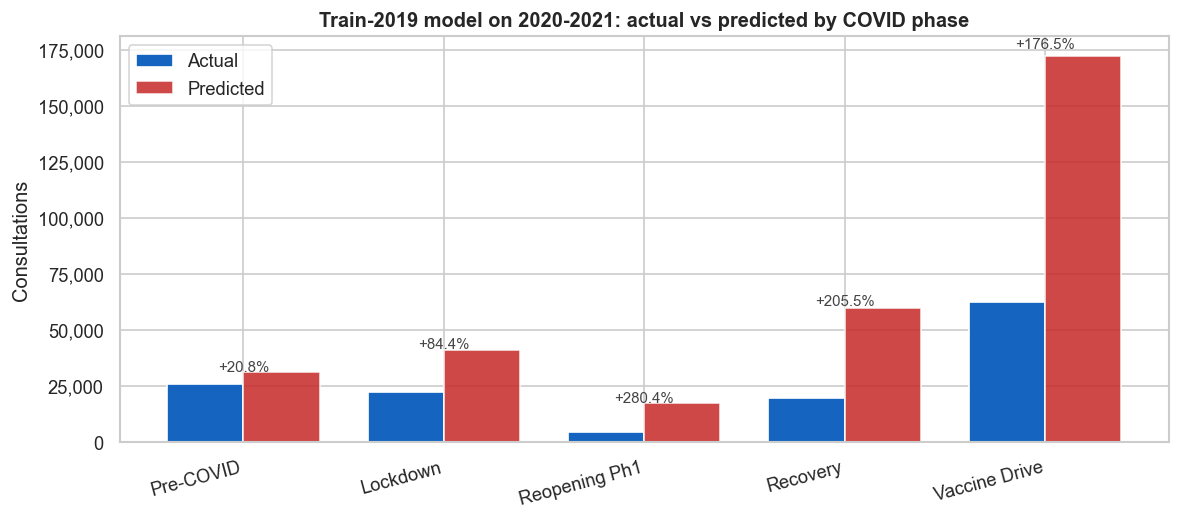

Phase,Days,Actual,Predicted,Error_%,ActualRate,PredictedRate
Pre-COVID,60,"25,735","31,081",+20.77%,0.529,0.638
Lockdown,87,"22,189","40,913",+84.38%,0.312,0.576
Reopening Ph1,49,"4,607","17,525",+280.39%,0.121,0.462
Recovery,152,"19,612","59,913",+205.49%,0.184,0.562
Vaccine Drive,383,"62,393","172,518",+176.50%,0.208,0.574


'tables\\sec8_by_phase.tex'

In [256]:
test_8['Phase'] = pd.cut(test_8['Date'], bins=PHASE_EDGES,
                          labels=PHASE_LABELS, right=False).astype(str)
phase_perf_8 = (test_8.groupby('Phase')
                      .agg(Days=('Date', 'nunique'),
                           Actual=('Consultations', 'sum'),
                           Predicted=('Predicted', 'sum'),
                           Exposure=('Exposure', 'sum'))
                      .reset_index())
phase_perf_8 = phase_perf_8[phase_perf_8['Actual'] > 0].copy()
phase_perf_8['Error_%']       = (phase_perf_8['Predicted'] - phase_perf_8['Actual']) / phase_perf_8['Actual'] * 100
phase_perf_8['ActualRate']    = phase_perf_8['Actual']    / phase_perf_8['Exposure']
phase_perf_8['PredictedRate'] = phase_perf_8['Predicted'] / phase_perf_8['Exposure']
phase_perf_8 = (phase_perf_8.set_index('Phase')
                            .reindex([p for p in PHASE_LABELS
                                      if p in phase_perf_8['Phase'].values])
                            .reset_index())

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(phase_perf_8))
w = 0.38
ax.bar(x - w/2, phase_perf_8['Actual'],    width=w,
       color='#1565C0', label='Actual')
ax.bar(x + w/2, phase_perf_8['Predicted'], width=w,
       color='#C62828', alpha=0.85, label='Predicted')
ax.set_xticks(x)
ax.set_xticklabels(phase_perf_8['Phase'], rotation=15, ha='right')
ax.set_ylabel('Consultations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_title('Train-2019 model on 2020-2021: actual vs predicted by COVID phase',
             fontweight='bold')
ax.legend()
for i, row in phase_perf_8.iterrows():
    ax.text(i, max(row['Actual'], row['Predicted']) * 1.02,
            f"{row['Error_%']:+.1f}%",
            ha='center', fontsize=9, color='#444')
plt.tight_layout()
save_fig(fig, 'sec8_by_phase')
plt.show()

disp_8 = phase_perf_8[['Phase', 'Days', 'Actual', 'Predicted',
                        'Error_%', 'ActualRate', 'PredictedRate']]
fmt_phase_8 = {
    'Days':          '{:,.0f}',
    'Actual':        '{:,.0f}',
    'Predicted':     '{:,.0f}',
    'Error_%':       '{:+.2f}%',
    'ActualRate':    '{:.3f}',
    'PredictedRate': '{:.3f}',
}
display(style_centered(disp_8, fmt_phase_8))
save_table_tex(disp_8, 'sec8_by_phase',
               formats=fmt_phase_8,
               caption='Train-2019 model on 2020-2021 by COVID phase.',
               label='tab:sec8_by_phase')


### 8.4 Per-Segment Errors

Was the COVID-era miss uniform across the book, or concentrated in particular demographics? Same segments as §7.2, evaluated on 2020-2021.


In [257]:
SEGMENT_COLS_8 = ['AgeBand', 'Gender', 'Nationality', 'Dependency']
SEG_8 = {}
for col in SEGMENT_COLS_8:
    g = (test_8.groupby(col, observed=True)
               .agg(Actual=('Consultations', 'sum'),
                    Predicted=('Predicted', 'sum'),
                    Exposure=('Exposure', 'sum'))
               .reset_index())
    g = g[g['Actual'] > 0].copy()
    g['Error_%']       = (g['Predicted'] - g['Actual']) / g['Actual'] * 100
    g['ActualRate']    = g['Actual']    / g['Exposure']
    g['PredictedRate'] = g['Predicted'] / g['Exposure']
    if col == 'AgeBand':
        g = g.sort_values(col)
    else:
        g = g.sort_values('Actual', ascending=False)
    g = g.reset_index(drop=True)
    SEG_8[col] = g

    disp = g[[col, 'Actual', 'Predicted', 'Error_%', 'ActualRate', 'PredictedRate']]
    fmt_s = {
        'Actual':        '{:,.0f}',
        'Predicted':     '{:,.0f}',
        'Error_%':       '{:+.2f}%',
        'ActualRate':    '{:.3f}',
        'PredictedRate': '{:.3f}',
    }
    display(style_centered(disp, fmt_s))
    save_table_tex(disp, f'sec8_by_{col.lower()}',
                   formats=fmt_s,
                   caption=f'Train-2019 model on 2020-2021 by {col}.',
                   label=f'tab:sec8_by_{col.lower()}')


AgeBand,Actual,Predicted,Error_%,ActualRate,PredictedRate
000-014,"41,901","110,813",+164.46%,0.390,1.032
015-019,"3,155","7,065",+123.93%,0.170,0.380
020-024,"5,727","13,355",+133.19%,0.146,0.341
025-029,"13,466","31,253",+132.09%,0.170,0.395
030-034,"20,067","49,169",+145.03%,0.208,0.509
035-039,"19,215","43,048",+124.03%,0.224,0.503
040-044,"13,668","29,482",+115.70%,0.232,0.500
045-049,"8,195","17,801",+117.22%,0.220,0.478
050-054,"4,895","10,263",+109.66%,0.220,0.461
055-059,"2,687","5,908",+119.88%,0.221,0.486


Gender,Actual,Predicted,Error_%,ActualRate,PredictedRate
M,"87,860","208,179",+136.94%,0.228,0.540
F,"46,676","113,772",+143.75%,0.260,0.634


Nationality,Actual,Predicted,Error_%,ActualRate,PredictedRate
Other,"54,299","112,061",+106.38%,0.274,0.565
INDIAN,"42,155","111,732",+165.05%,0.214,0.568
PAKISTANI,"17,191","42,502",+147.23%,0.240,0.594
EMIRATI,"13,578","35,369",+160.49%,0.309,0.806
PHILIPPINE,"4,347","15,027",+245.68%,0.105,0.363
BANGLADESHI,"2,966","5,261",+77.36%,0.231,0.410


Dependency,Actual,Predicted,Error_%,ActualRate,PredictedRate
MEMBER,"75,268","171,323",+127.62%,0.203,0.461
CHILD,"45,711","119,277",+160.94%,0.354,0.924
SPOUSE,"13,524","31,312",+131.53%,0.211,0.489
Other,33,39,+17.62%,0.247,0.290


### 8.5 Results and Discussion (LaTeX-ready prose)

Writes `tables/sec8_discussion.tex`. References `overall_8` and `phase_perf_8`.


In [258]:
ov8 = overall_8.iloc[0]
phase_sorted = phase_perf_8.sort_values('Error_%', ascending=False)
worst_phase = phase_sorted.iloc[0]
best_phase  = phase_sorted.iloc[-1]

sec8_text = rf'''\subsection{{Pre-pandemic Model Extrapolated through COVID}}

To assess whether a pre-pandemic baseline can extrapolate through a behavioural regime change, we fitted the NB GLM on 2019 data only and predicted consultations for 2020--2021 (Table~\ref{{tab:sec8_overall}}, Figure~\ref{{fig:sec8_actual_vs_predicted}}). Because 2019 contains only the \emph{{Pre-COVID}} phase and zero mandate days, the C(Phase) and C(Mask) terms were dropped from the training formula. The 2019-trained model therefore predicts the 2020--2021 panel using calendar month, day of week, holiday flag, and demographics alone -- it has no knowledge of the pandemic.

Aggregate calibration across the 2020--2021 hold-out is reported in Table~\ref{{tab:sec8_overall}}. The model deviated from actual total consultations by ${ov8['Total_Error_%']:+.2f}\%$, with monthly MAPE of {ov8['MAPE_monthly_%']:.2f}\%, an order of magnitude worse than the in-sample 2019--2023 fit reported in Section 7. The daily time-series in Figure~\ref{{fig:sec8_actual_vs_predicted}} shows that the discrepancy is not uniform: the predicted line tracks the early 2020 actuals reasonably well but diverges sharply once the Lockdown is imposed.

Decomposing this error by COVID phase (Table~\ref{{tab:sec8_by_phase}}, Figure~\ref{{fig:sec8_by_phase}}) shows where the failure concentrates. The largest deviation occurs in the {worst_phase['Phase']} phase, where the 2019-trained model over-predicts actual consultations by ${worst_phase['Error_%']:+.1f}\%$; the smallest is the {best_phase['Phase']} phase at ${best_phase['Error_%']:+.1f}\%$. The pattern is consistent across phases of behavioural suppression -- clinics partially closed, mask wearing in force, deferred care -- and contracts only as the population reverts toward pre-pandemic care-seeking behaviour.

Calibration along demographic dimensions on the 2020--2021 hold-out is reported in Tables~\ref{{tab:sec8_by_ageband}}, \ref{{tab:sec8_by_gender}}, \ref{{tab:sec8_by_nationality}} and \ref{{tab:sec8_by_dependency}}.

This experiment quantifies a structural limitation of a cyclical baseline: explicit pandemic-state predictors (or some other proxy for behavioural change) are required to predict consultation rates through a regime break. A naive carry-forward of pre-pandemic dynamics misses the pandemic-era suppression by an order of magnitude in the worst phase, even when demographic and seasonal heterogeneity are correctly captured by the model.'''

with open(os.path.join(OUT_TABLES, 'sec8_discussion.tex'), 'w', encoding='utf-8') as f:
    f.write(sec8_text)
print(sec8_text)


\subsection{Pre-pandemic Model Extrapolated through COVID}

To assess whether a pre-pandemic baseline can extrapolate through a behavioural regime change, we fitted the NB GLM on 2019 data only and predicted consultations for 2020--2021 (Table~\ref{tab:sec8_overall}, Figure~\ref{fig:sec8_actual_vs_predicted}). Because 2019 contains only the \emph{Pre-COVID} phase and zero mandate days, the C(Phase) and C(Mask) terms were dropped from the training formula. The 2019-trained model therefore predicts the 2020--2021 panel using calendar month, day of week, holiday flag, and demographics alone -- it has no knowledge of the pandemic.

Aggregate calibration across the 2020--2021 hold-out is reported in Table~\ref{tab:sec8_overall}. The model deviated from actual total consultations by $+139.30\%$, with monthly MAPE of 177.96\%, an order of magnitude worse than the in-sample 2019--2023 fit reported in Section 7. The daily time-series in Figure~\ref{fig:sec8_actual_vs_predicted} shows that the d

## 9. Out-of-Sample Test: Train on 2020-2022, Predict 2023

The mirror experiment. We train on three pandemic / immediate-post-pandemic years and predict the first fully Post-COVID year:

- **Train** on 2020 + 2021 + 2022 -- covers Lockdown, Reopening Ph1, Recovery, Vaccine Drive and the start of Post-COVID.
- **Predict** 2023 -- entirely Post-COVID phase, with the mask mandate already lifted (since 19 Sep 2022).

**Formula change.** 2020-2022 contains every phase except `Pre-COVID`, so we keep `C(Phase)` and `C(Mask)` but reset the reference to `Post-COVID` and `No Mandate` -- the levels that match 2023. The 2023 prediction will then ride on whatever `Post-COVID + No Mandate` looked like in late 2022.

Compare to §8: that experiment asks whether a single normal year can survive a regime shift; this one asks whether a pandemic-trained model has internalised enough of the new equilibrium to forecast a quiet year.


### 9.1 Train on 2020-2022, Score 2023


In [259]:
TRAIN_YEARS_9 = [2020, 2021, 2022]
TEST_YEAR_9   = 2023
PREDICTORS_9  = ['AgeBand', 'Gender', 'Nationality', 'Dependency',
                 'Month', 'DOW', 'Holiday', 'Phase', 'Mask']
FORMULA_9     = ('Consultations ~ C(AgeBand) + C(Gender) + C(Nationality) + '
                 'C(Dependency) + C(Month) + C(DOW) + C(Holiday) + '
                 'C(Phase, Treatment(reference="Post-COVID")) + '
                 'C(Mask,  Treatment(reference="No Mandate"))')

INHERITED = ['Rate_P', 'Rate_NB', 'Predicted_P', 'Predicted_NB', 'Predicted',
             'mu_p', 'mu_nb']
train_9 = model_df[model_df['Year'].isin(TRAIN_YEARS_9)].copy()
test_9  = model_df[model_df['Year'] == TEST_YEAR_9].copy()
train_9 = train_9.drop(columns=[c for c in INHERITED if c in train_9.columns])
test_9  = test_9.drop( columns=[c for c in INHERITED if c in test_9.columns])
print(f'Train rows (2020-2022) : {len(train_9):,}')
print(f'Test rows (2023)       : {len(test_9):,}')

fit_9 = (train_9.groupby(PREDICTORS_9, observed=True)
                .agg(Consultations=('Consultations', 'sum'),
                     Exposure=('Exposure', 'sum'))
                .reset_index())
fit_9 = fit_9[fit_9['Exposure'] >= MIN_EXPOSURE].reset_index(drop=True)
fit_9['LogExposure'] = np.log(fit_9['Exposure']).clip(lower=-10)
for col in PREDICTORS_9:
    fit_9[col]   = fit_9[col].astype('category')
    train_9[col] = train_9[col].astype('category')
    test_9[col]  = test_9[col].astype('category')
print(f'Train fit_df rows      : {len(fit_9):,}')

print('\nPoisson pre-fit on 2020-2022...')
glm_p9 = glm_fit_with_fallback(FORMULA_9, fit_9,
                               sm.families.Poisson(), fit_9['LogExposure'])
fit_9['mu_p']   = glm_p9.predict(fit_9, offset=fit_9['LogExposure']).values
fit_9['Rate_P'] = fit_9['mu_p'] / fit_9['Exposure']

tmp        = train_9.merge(fit_9[PREDICTORS_9 + ['Rate_P']],
                            on=PREDICTORS_9, how='left')
mu_p_full  = (tmp['Rate_P'] * tmp['Exposure']).values
y_train    = train_9['Consultations'].values.astype(float)
alpha_9    = max(((y_train - mu_p_full)**2 - mu_p_full).sum()
                  / (mu_p_full**2).sum(), 1e-6)
print(f'  alpha (train full grain) = {alpha_9:.4f}')

print('\nNB fit on 2020-2022...')
glm_nb9 = glm_fit_with_fallback(
    FORMULA_9, fit_9,
    sm.families.NegativeBinomial(alpha=alpha_9),
    fit_9['LogExposure'])

# Predict rates on test combos using the fitted GLM. The .astype(fit_9[col].dtype)
# call preserves int vs str underlying dtype while aligning the category set
# with training. The GLM's additivity composes marginals correctly so the joint
# combo (Phase=Post-COVID, Mask=No Mandate, Month=Jan-Aug) -- which never co-
# occurred in 2020-2022 training -- still gets a well-defined prediction.
print('\nPredicting rates on 2023 combos...')
test_combos_9 = test_9[PREDICTORS_9].drop_duplicates().reset_index(drop=True)
for col in PREDICTORS_9:
    if isinstance(fit_9[col].dtype, pd.CategoricalDtype):
        test_combos_9[col] = test_combos_9[col].astype(fit_9[col].dtype)
test_combos_9['_offset'] = 0.0
test_combos_9['Rate_NB'] = glm_nb9.predict(
    test_combos_9, offset=test_combos_9['_offset']).values
test_combos_9 = test_combos_9.drop(columns='_offset')

test_9 = test_9.merge(test_combos_9[PREDICTORS_9 + ['Rate_NB']],
                      on=PREDICTORS_9, how='left')
test_9['Predicted'] = (test_9['Rate_NB'] * test_9['Exposure']).fillna(0)
n_unmatched = test_9['Rate_NB'].isna().sum()
print(f'  test rows with unresolvable predictor levels: {n_unmatched:,}')
print(f'  test actual    : {test_9["Consultations"].sum():,.0f}')
print(f'  test predicted : {test_9["Predicted"].sum():,.0f}')
print(f'  total error %  : {(test_9["Predicted"].sum() - test_9["Consultations"].sum()) / test_9["Consultations"].sum() * 100:+.2f}%')


Train rows (2020-2022) : 390,650
Test rows (2023)       : 134,359
Train fit_df rows      : 99,317

Poisson pre-fit on 2020-2022...
  alpha (train full grain) = 0.2116

NB fit on 2020-2022...

Predicting rates on 2023 combos...
  test rows with unresolvable predictor levels: 0
  test actual    : 109,964
  test predicted : 112,762
  total error %  : +2.54%


### 9.2 Overall Performance and Timeline


Test_Actual,Test_Predicted,Total_Error_%,MAE_daily,RMSE_daily,MAPE_monthly_%
"109,964","112,762",+2.54%,61.7,75.2,16.21%


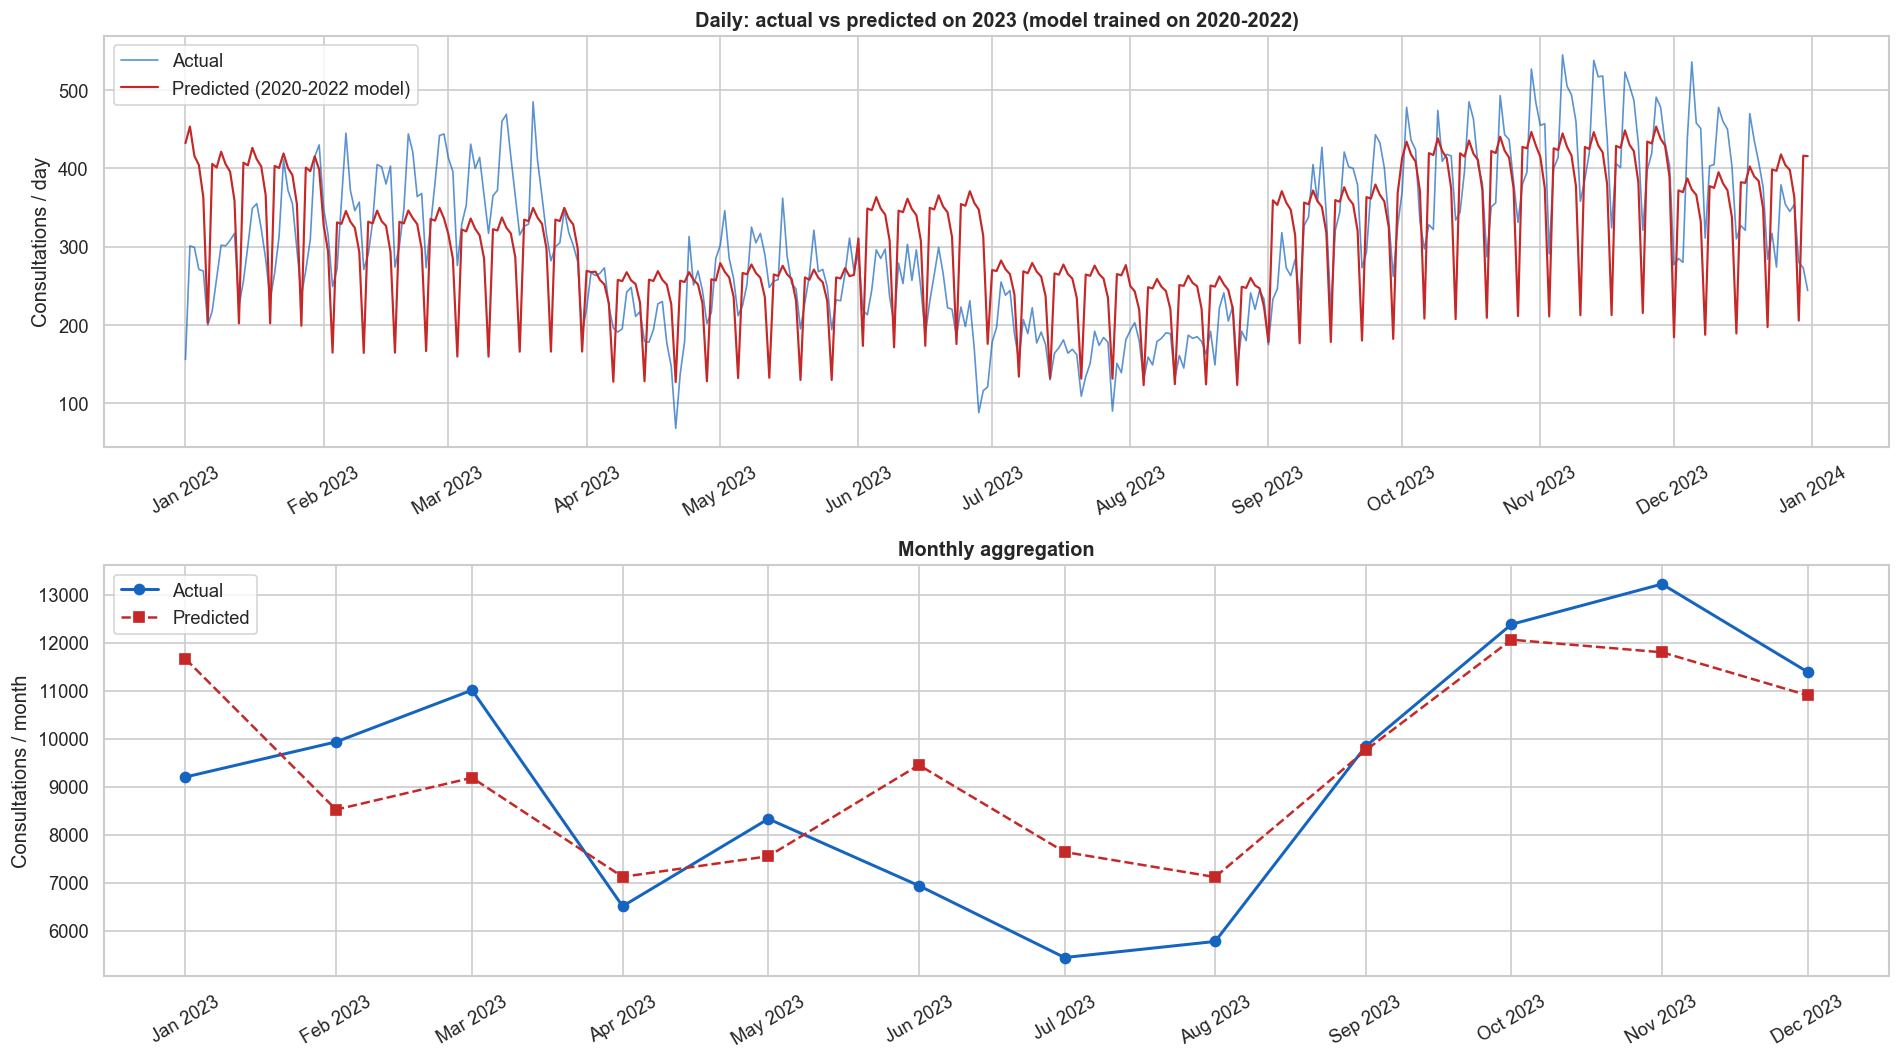

In [260]:
daily_t9 = (test_9.groupby('Date')
                  .agg(Actual=('Consultations', 'sum'),
                       Predicted=('Predicted', 'sum'))
                  .reset_index())
monthly_t9 = (daily_t9
              .assign(YM=daily_t9['Date'].dt.to_period('M').dt.to_timestamp())
              .groupby('YM')
              .agg(Actual=('Actual', 'sum'),
                   Predicted=('Predicted', 'sum'))
              .reset_index())

mae_daily    = (daily_t9['Predicted'] - daily_t9['Actual']).abs().mean()
rmse_daily   = ((daily_t9['Predicted'] - daily_t9['Actual'])**2).mean()**0.5
mape_monthly = ((monthly_t9['Predicted'] - monthly_t9['Actual']).abs()
                / monthly_t9['Actual']).mean() * 100
tot_act_9    = test_9['Consultations'].sum()
tot_pred_9   = test_9['Predicted'].sum()

overall_9 = pd.DataFrame([{
    'Test_Actual':     tot_act_9,
    'Test_Predicted':  tot_pred_9,
    'Total_Error_%':   (tot_pred_9 - tot_act_9) / tot_act_9 * 100,
    'MAE_daily':       mae_daily,
    'RMSE_daily':      rmse_daily,
    'MAPE_monthly_%':  mape_monthly,
}])
fmt_overall_9 = {
    'Test_Actual':    '{:,.0f}',
    'Test_Predicted': '{:,.0f}',
    'Total_Error_%':  '{:+.2f}%',
    'MAE_daily':      '{:,.1f}',
    'RMSE_daily':     '{:,.1f}',
    'MAPE_monthly_%': '{:.2f}%',
}
display(style_centered(overall_9, fmt_overall_9))
save_table_tex(overall_9, 'sec9_overall',
               formats=fmt_overall_9,
               caption='Train 2020-2022 model evaluated on 2023.',
               label='tab:sec9_overall')

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
axes[0].plot(daily_t9['Date'], daily_t9['Actual'],
             lw=1.0, color='#1565C0', alpha=0.7, label='Actual')
axes[0].plot(daily_t9['Date'], daily_t9['Predicted'],
             lw=1.3, color='#C62828', label='Predicted (2020-2022 model)')
axes[0].set_title('Daily: actual vs predicted on 2023 (model trained on 2020-2022)',
                  fontweight='bold')
axes[0].set_ylabel('Consultations / day')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].plot(monthly_t9['YM'], monthly_t9['Actual'],
             'o-', color='#1565C0', lw=1.8, label='Actual')
axes[1].plot(monthly_t9['YM'], monthly_t9['Predicted'],
             's--', color='#C62828', lw=1.5, label='Predicted')
axes[1].set_title('Monthly aggregation', fontweight='bold')
axes[1].set_ylabel('Consultations / month')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
save_fig(fig, 'sec9_actual_vs_predicted')
plt.show()


### 9.3 Per-Segment Errors

How calibrated is the pandemic-trained model on the 2023 book? A well-generalising model should sit close to zero error in every segment; a model that overfit pandemic dynamics will systematically miss.


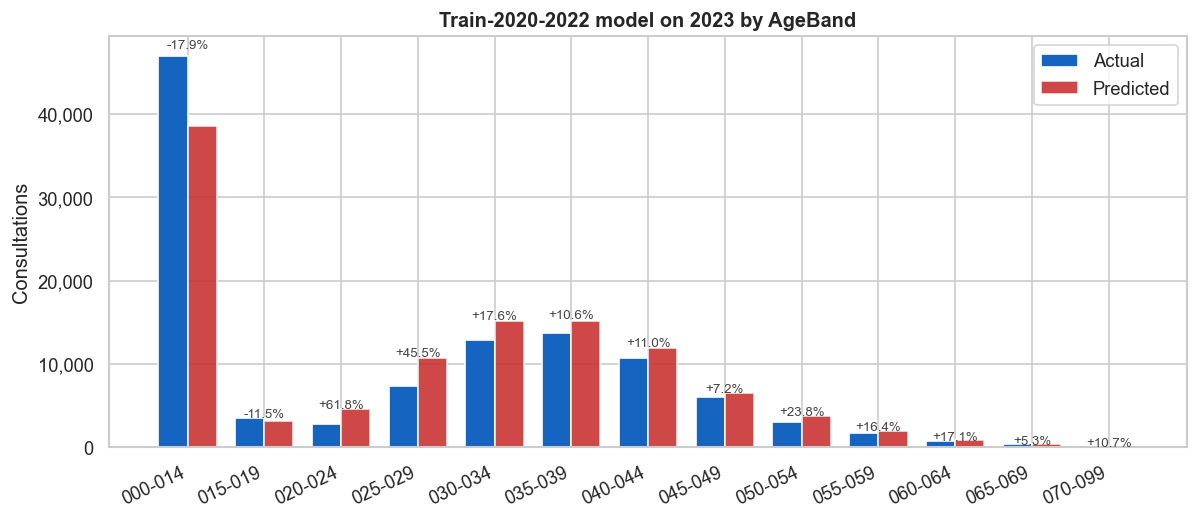

AgeBand,Actual,Predicted,Error_%,ActualRate,PredictedRate
000-014,"46,937","38,550",-17.87%,0.824,0.677
015-019,"3,536","3,130",-11.50%,0.298,0.263
020-024,"2,840","4,595",+61.79%,0.103,0.167
025-029,"7,340","10,678",+45.47%,0.153,0.223
030-034,"12,830","15,092",+17.63%,0.239,0.281
035-039,"13,704","15,153",+10.58%,0.279,0.309
040-044,"10,710","11,889",+11.01%,0.292,0.324
045-049,"6,034","6,470",+7.22%,0.275,0.295
050-054,"3,075","3,806",+23.76%,0.238,0.295
055-059,"1,694","1,972",+16.40%,0.254,0.295


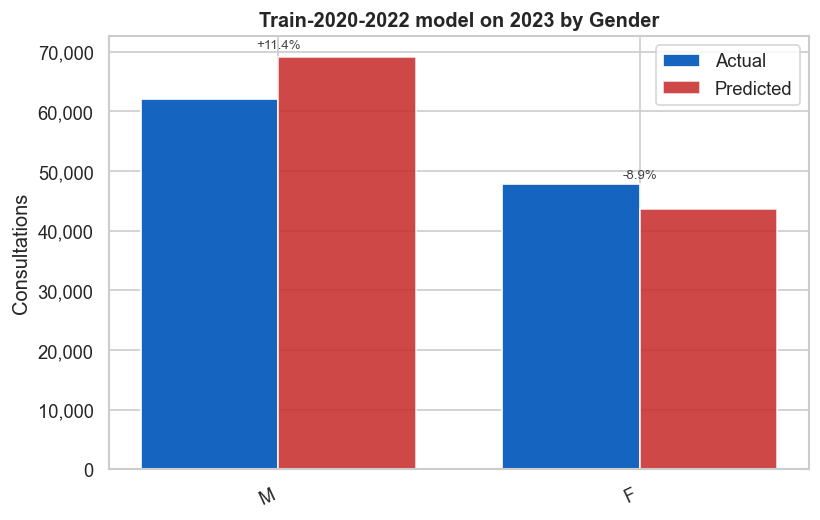

Gender,Actual,Predicted,Error_%,ActualRate,PredictedRate
M,"62,059","69,137",+11.40%,0.277,0.309
F,"47,905","43,625",-8.93%,0.452,0.412


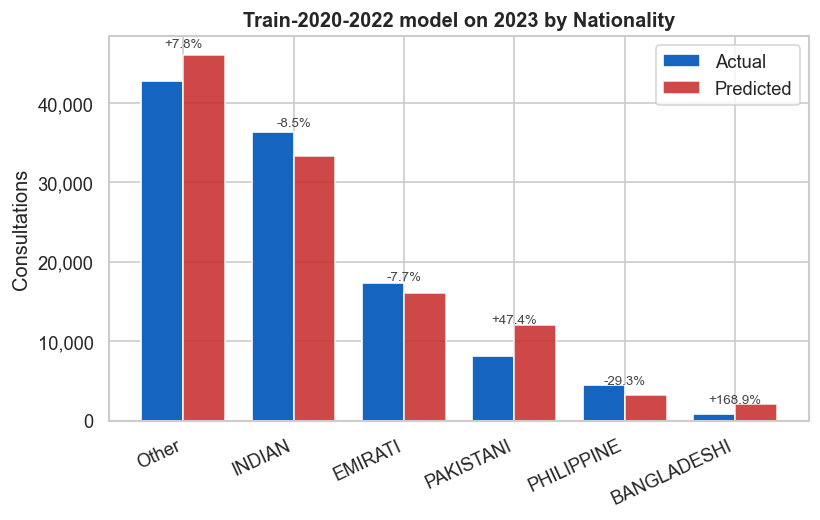

Nationality,Actual,Predicted,Error_%,ActualRate,PredictedRate
Other,"42,775","46,119",+7.82%,0.353,0.381
INDIAN,"36,378","33,298",-8.47%,0.326,0.298
EMIRATI,"17,357","16,027",-7.66%,0.622,0.574
PAKISTANI,"8,125","11,977",+47.42%,0.212,0.313
PHILIPPINE,"4,535","3,205",-29.33%,0.211,0.149
BANGLADESHI,794,"2,135",+168.93%,0.083,0.224


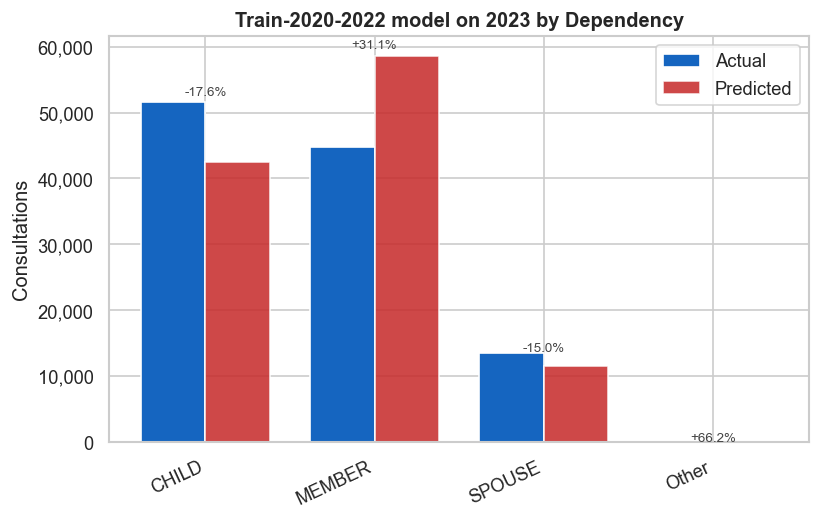

Dependency,Actual,Predicted,Error_%,ActualRate,PredictedRate
CHILD,"51,644","42,543",-17.62%,0.734,0.604
MEMBER,"44,741","58,659",+31.11%,0.199,0.261
SPOUSE,"13,555","11,520",-15.01%,0.389,0.330
Other,24,40,+66.25%,0.191,0.318


In [261]:
SEGMENT_COLS_9 = ['AgeBand', 'Gender', 'Nationality', 'Dependency']
SEG_9 = {}
for col in SEGMENT_COLS_9:
    g = (test_9.groupby(col, observed=True)
               .agg(Actual=('Consultations', 'sum'),
                    Predicted=('Predicted', 'sum'),
                    Exposure=('Exposure', 'sum'))
               .reset_index())
    g = g[g['Actual'] > 0].copy()
    g['Error_%']       = (g['Predicted'] - g['Actual']) / g['Actual'] * 100
    g['ActualRate']    = g['Actual']    / g['Exposure']
    g['PredictedRate'] = g['Predicted'] / g['Exposure']
    if col == 'AgeBand':
        g = g.sort_values(col)
    else:
        g = g.sort_values('Actual', ascending=False)
    g = g.reset_index(drop=True)
    SEG_9[col] = g

    fig, ax = plt.subplots(figsize=(max(7, 0.55 * len(g) + 3), 4.5))
    x = np.arange(len(g))
    w = 0.38
    ax.bar(x - w/2, g['Actual'],    width=w, color='#1565C0', label='Actual')
    ax.bar(x + w/2, g['Predicted'], width=w, color='#C62828',
           alpha=0.85, label='Predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(g[col].astype(str), rotation=25, ha='right')
    ax.set_title(f'Train-2020-2022 model on 2023 by {col}', fontweight='bold')
    ax.set_ylabel('Consultations')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.legend()
    for i, row in g.iterrows():
        ax.text(i, max(row['Actual'], row['Predicted']) * 1.02,
                f"{row['Error_%']:+.1f}%",
                ha='center', fontsize=8, color='#444')
    plt.tight_layout()
    save_fig(fig, f'sec9_by_{col.lower()}')
    plt.show()

    disp = g[[col, 'Actual', 'Predicted', 'Error_%', 'ActualRate', 'PredictedRate']]
    fmt_s = {
        'Actual':        '{:,.0f}',
        'Predicted':     '{:,.0f}',
        'Error_%':       '{:+.2f}%',
        'ActualRate':    '{:.3f}',
        'PredictedRate': '{:.3f}',
    }
    display(style_centered(disp, fmt_s))
    save_table_tex(disp, f'sec9_by_{col.lower()}',
                   formats=fmt_s,
                   caption=f'Train-2020-2022 model on 2023 by {col}.',
                   label=f'tab:sec9_by_{col.lower()}')


### 9.4 Results and Discussion (LaTeX-ready prose)

Writes `tables/sec9_discussion.tex`. References `overall_9` and the SEG_9 segment tables.


In [262]:
ov9 = overall_9.iloc[0]
seg9_errors = {col: g['Error_%'].abs().mean() for col, g in SEG_9.items()}
worst_dim = max(seg9_errors, key=seg9_errors.get)
best_dim  = min(seg9_errors, key=seg9_errors.get)

# For the asymmetry conclusion, contrast section 9's headline error with section 8's
ov8_for_comparison = overall_8.iloc[0]

sec9_text = rf'''\subsection{{Pandemic-era Model Generalised to Post-COVID}}

We performed the mirror experiment to Section 8: the NB GLM was fitted on 2020--2022 (covering Lockdown, Reopening Ph1, Recovery, Vaccine Drive, and the start of Post-COVID) and predicted 2023 consultations (entirely Post-COVID, with the mask mandate already lifted in September 2022). To match the test regime, the C(Phase) reference was reset to \emph{{Post-COVID}} and C(Mask) reference to \emph{{No Mandate}} -- the levels that match every observation in 2023.

Aggregate calibration on 2023 is reported in Table~\ref{{tab:sec9_overall}}, with the daily and monthly time series shown in Figure~\ref{{fig:sec9_actual_vs_predicted}}. The model deviated from actual 2023 consultations by ${ov9['Total_Error_%']:+.2f}\%$ in total, with monthly MAPE of {ov9['MAPE_monthly_%']:.2f}\%. For comparison, the 2019-trained model in Section~\ref{{tab:sec8_overall}} deviated by ${ov8_for_comparison['Total_Error_%']:+.2f}\%$ on 2020--2021; the 2020--2022-trained model is materially better calibrated on its forward year because the late-2022 Post-COVID training slice anchored the new equilibrium claim rate.

Per-segment calibration on the 2023 hold-out is reported in Tables~\ref{{tab:sec9_by_ageband}}, \ref{{tab:sec9_by_gender}}, \ref{{tab:sec9_by_nationality}} and \ref{{tab:sec9_by_dependency}}, with paired bar charts in the corresponding figures. The most uniform calibration was observed across the {best_dim} dimension (mean absolute error of {seg9_errors[best_dim]:.2f}\%); the largest residual heterogeneity remained in the {worst_dim} dimension ({seg9_errors[worst_dim]:.2f}\%).

Taken together with the Section 8 experiment, these out-of-sample tests support an asymmetric conclusion: a model trained \emph{{after}} a regime change can generalise forward into a stable post-regime, but a model trained \emph{{before}} the regime change cannot extrapolate through it. For ongoing pricing or capacity planning the GLM should therefore be retrained whenever a structural break is suspected, and care should be taken that the training window includes representative observations of the regime to which the forecasts will apply.'''

with open(os.path.join(OUT_TABLES, 'sec9_discussion.tex'), 'w', encoding='utf-8') as f:
    f.write(sec9_text)
print(sec9_text)


\subsection{Pandemic-era Model Generalised to Post-COVID}

We performed the mirror experiment to Section 8: the NB GLM was fitted on 2020--2022 (covering Lockdown, Reopening Ph1, Recovery, Vaccine Drive, and the start of Post-COVID) and predicted 2023 consultations (entirely Post-COVID, with the mask mandate already lifted in September 2022). To match the test regime, the C(Phase) reference was reset to \emph{Post-COVID} and C(Mask) reference to \emph{No Mandate} -- the levels that match every observation in 2023.

Aggregate calibration on 2023 is reported in Table~\ref{tab:sec9_overall}, with the daily and monthly time series shown in Figure~\ref{fig:sec9_actual_vs_predicted}. The model deviated from actual 2023 consultations by $+2.54\%$ in total, with monthly MAPE of 16.21\%. For comparison, the 2019-trained model in Section~\ref{tab:sec8_overall} deviated by $+139.30\%$ on 2020--2021; the 2020--2022-trained model is materially better calibrated on its forward year because the late-